## 1. Data Ingestion & Shape Verification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../artifacts/train.csv')
print("Dataset loaded successfully.")
print("-" * 60)
print("Shape   :", df.shape)
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])
print("-" * 60)
df.head()

Dataset loaded successfully.
------------------------------------------------------------
Shape   : (59288, 29)
Rows    : 59288
Columns : 29
------------------------------------------------------------


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,760827,4.499810,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",4,1.5,Real Bed,flexible,False,...,34.109039,-118.273390,Comfortable guesthouse in Los Feliz,Los Feliz,12,97.0,https://a0.muscache.com/im/pictures/68126735/8...,90027,2.0,3.0
1,3257345,3.806662,Apartment,Entire home/apt,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",2,1.0,Real Bed,strict,True,...,40.812897,-73.919163,Garden apartment w/ parking! Colorful Cheery S...,Mott Haven,6,87.0,https://a0.muscache.com/im/pictures/de651e45-a...,10454,1.0,1.0
2,13355012,5.075174,Apartment,Entire home/apt,"{TV,""Air conditioning"",Kitchen,Heating,""Smoke ...",4,1.0,Real Bed,strict,True,...,40.737643,-73.953309,Greenpoint Studio w/ KING bed and Sofabed!,Greenpoint,4,80.0,https://a0.muscache.com/im/pictures/02fe96c0-8...,11222,0.0,2.0
3,4565981,4.442651,Apartment,Private room,{},2,1.0,Real Bed,flexible,True,...,37.759935,-122.420558,Comfy Valenica Street bedroom,Mission District,0,NaN,https://a0.muscache.com/im/pictures/03292fda-2...,94110,1.0,1.0
4,6940108,4.744932,Apartment,Entire home/apt,"{Internet,""Wireless Internet"",""Air conditionin...",3,1.0,Real Bed,moderate,True,...,40.683363,-73.949490,charming brooklyn apartment,Bedford-Stuyvesant,16,99.0,NaN,11216,1.0,1.0


In [2]:
df.sample(5)

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
42610,15767892,4.605170,Apartment,Private room,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",2,1.0,Real Bed,flexible,False,...,40.775704,-73.921954,Astoria Park & Pool-Apartment Min from mid-town.,Astoria,2,100.0,https://a0.muscache.com/im/pictures/4d150bfd-e...,11102,1.0,1.0
32463,18463851,5.176150,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",4,1.0,Real Bed,moderate,False,...,40.731717,-73.984604,Spacious East Village 2 bedroom with living room.,East Village,2,100.0,https://a0.muscache.com/im/pictures/74114c4d-d...,NaN,2.0,2.0
57652,16416330,4.605170,House,Private room,"{TV,""Wireless Internet"",""Smoke detector"",""Firs...",1,0.5,Real Bed,flexible,False,...,37.750121,-122.442831,Test1,Noe Valley,0,NaN,https://a0.muscache.com/im/pictures/109766271/...,94401,1.0,1.0
32154,7839972,4.997212,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",4,1.0,Real Bed,strict,True,...,38.889252,-77.000861,Elegant 1 BR East Capitol St Apt,Capitol Hill,17,92.0,https://a0.muscache.com/im/pictures/16596709/d...,20003,1.0,2.0
21085,9734844,4.787492,Apartment,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",1,1.0,Real Bed,flexible,False,...,34.101729,-118.314865,hollywood luxury 2 bed private bathroom,Hollywood,0,NaN,https://a0.muscache.com/im/pictures/5186da3b-a...,90028,1.0,2.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59288 entries, 0 to 59287
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      59288 non-null  int64  
 1   log_price               59288 non-null  float64
 2   property_type           59288 non-null  str    
 3   room_type               59288 non-null  str    
 4   amenities               59288 non-null  str    
 5   accommodates            59288 non-null  int64  
 6   bathrooms               59128 non-null  float64
 7   bed_type                59288 non-null  str    
 8   cancellation_policy     59288 non-null  str    
 9   cleaning_fee            59288 non-null  bool   
 10  city                    59288 non-null  str    
 11  description             59288 non-null  str    
 12  first_review            46586 non-null  str    
 13  host_has_profile_pic    59128 non-null  str    
 14  host_identity_verified  59128 non-null  str    
 

In [4]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


id                            0
log_price                     0
property_type                 0
room_type                     0
amenities                     0
accommodates                  0
bathrooms                   160
bed_type                      0
cancellation_policy           0
cleaning_fee                  0
city                          0
description                   0
first_review              12702
host_has_profile_pic        160
host_identity_verified      160
host_response_rate        14641
host_since                  160
instant_bookable              0
last_review               12672
latitude                      0
longitude                     0
name                          0
neighbourhood              5509
number_of_reviews             0
review_scores_rating      13395
thumbnail_url              6587
zipcode                     761
bedrooms                     78
beds                        104
dtype: int64

In [5]:
df.describe()

,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,5.928800e+04,59288.000000,59288.000000,59128.000000,59288.000000,59288.000000,59288.000000,45893.000000,59210.000000,59184.000000
mean,1.126102e+07,4.780538,3.152054,1.236183,38.450807,-92.349408,20.935805,94.076526,1.265817,1.712862
std,6.087273e+06,0.717547,2.153512,0.582392,3.080455,21.688276,37.950408,7.807910,0.849750,1.259406
min,9.410000e+02,0.000000,1.000000,0.000000,33.338905,-122.511500,0.000000,20.000000,0.000000,0.000000
25%,6.245493e+06,4.304065,2.000000,1.000000,34.128782,-118.341975,1.000000,92.000000,1.000000,1.000000
50%,1.224695e+07,4.700480,2.000000,1.000000,40.663197,-76.995645,6.000000,96.000000,1.000000,1.000000
75%,1.640730e+07,5.220356,4.000000,1.000000,40.746167,-73.954621,23.000000,100.000000,1.000000,2.000000
max,2.123090e+07,7.600402,16.000000,8.000000,42.390437,-70.999166,605.000000,100.000000,10.000000,18.000000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.select_dtypes(include='number').corr()


,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
id,1.000000,-0.007145,-0.005052,-0.002602,-0.004732,-0.004016,0.003308,0.001401,-0.007027,-0.009257
log_price,-0.007145,1.000000,0.569175,0.352129,0.000427,-0.045283,-0.030763,0.092239,0.475462,0.443746
accommodates,-0.005052,0.569175,1.000000,0.501912,-0.078609,-0.085330,0.041228,-0.016969,0.709469,0.808495
bathrooms,-0.002602,0.352129,0.501912,1.000000,-0.135217,-0.132037,-0.041559,0.008341,0.587305,0.525726
latitude,-0.004732,0.000427,-0.078609,-0.135217,1.000000,0.896401,-0.016788,-0.035274,-0.058001,-0.080239
longitude,-0.004016,-0.045283,-0.085330,-0.132037,0.896401,1.000000,-0.049189,-0.050375,-0.074557,-0.082128
number_of_reviews,0.003308,-0.030763,0.041228,-0.041559,-0.016788,-0.049189,1.000000,0.012341,-0.034718,0.029684
review_scores_rating,0.001401,0.092239,-0.016969,0.008341,-0.035274,-0.050375,0.012341,1.000000,0.011340,-0.027071
bedrooms,-0.007027,0.475462,0.709469,0.587305,-0.058001,-0.074557,-0.034718,0.011340,1.000000,0.708492
beds,-0.009257,0.443746,0.808495,0.525726,-0.080239,-0.082128,0.029684,-0.027071,0.708492,1.000000


Problem Statement 1: Dynamic Pricing Recommendation Engine (Primary ML Focus)

The Question: How accurately can we predict the optimal nightly price for an Airbnb listing based on its location, physical characteristics, and host policies?

The Business Value: New Airbnb hosts often struggle to price their properties competitively. Pricing too high leads to vacancies, while pricing too low leaves money on the table.

How it fits your project: This is the core of your Flask/Streamlit Web App. You will build a regression model that takes inputs from a user (e.g., City: NYC, Room Type: Entire Home, Accommodates: 4) and outputs a suggested nightly price (by predicting the log_price and converting it back to regular dollars).

Problem Statement 2: Market Analysis for Real Estate Investors (Power BI Focus)

The Question: Which US cities, neighborhoods, and property configurations offer the most lucrative opportunities for short-term rental investments?

The Business Value: Real estate investors want to know where to buy their next property. They need to understand pricing trends, market saturation (using review counts as a proxy for demand), and the premium commanded by specific amenities or property types.

How it fits your project: This is the foundation of your Power BI Dashboard. You can build interactive map visuals showing high-value clusters, slicers to compare the average price of a "Private Room" in SF vs. Chicago, and charts showing how cancellation policies or cleaning fees impact the final listing price.

Problem Statement 3: Guest Experience & Rating Predictor (Advanced ML/Insights Focus)

The Question: What listing features and host behaviors are the strongest predictors of achieving a top-tier review score (e.g., review_scores_rating > 95)?

The Business Value: Property managers want to know what actually matters to guests. Does having an instant booking option, a strict cancellation policy, or a high number of bathrooms impact customer satisfaction more?

How it fits your project: You can use the feature importance scores (like SHAP values) from your machine learning model to generate a "Host Insights" section in your web app or dashboard, showing hosts exactly which features they should upgrade to improve their ratings.

Tackling Problem 1 and Problem 2 together will give you a standout, full-stack portfolio piece.

Are you ready to move on to Part 4 and write the data_transformation.py script to get these features ready for the machine learning model?

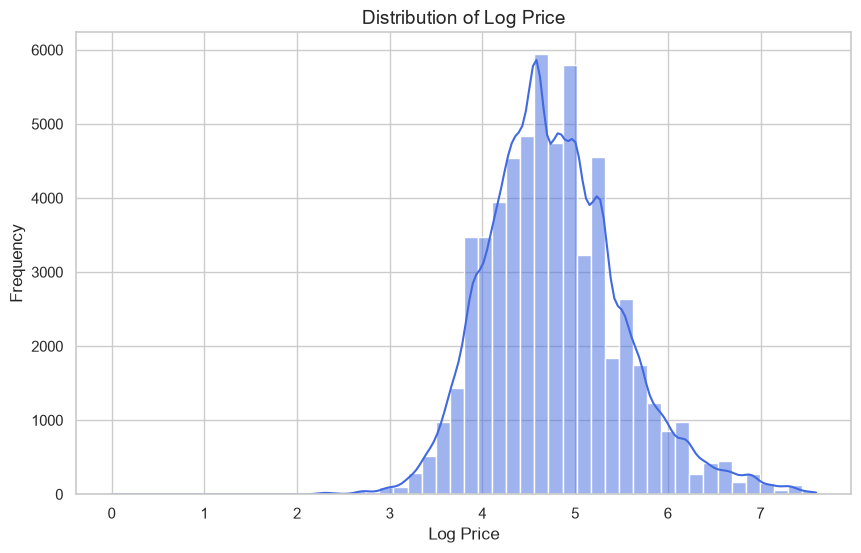

In [8]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='log_price', kde=True, bins=50, color='royalblue')
plt.title('Distribution of Log Price', fontsize=14)
plt.xlabel('Log Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

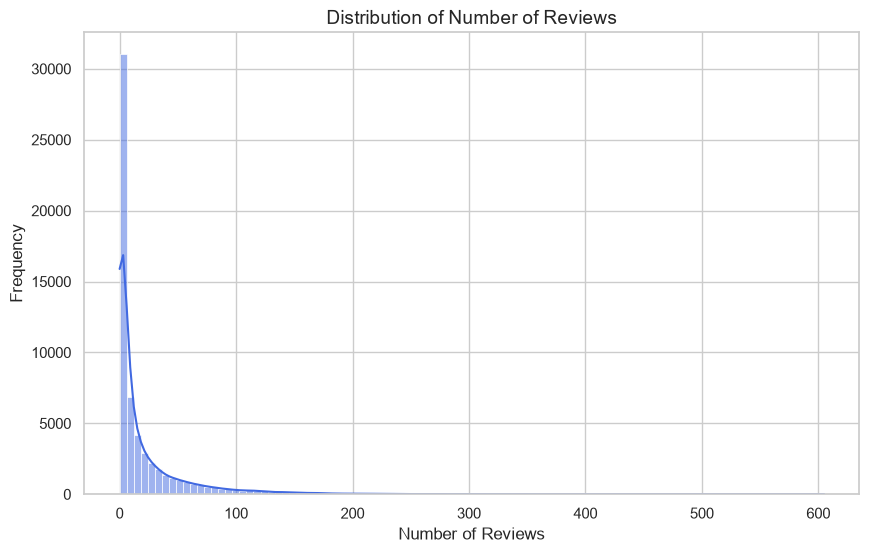

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='number_of_reviews', kde=True, bins=100, color='royalblue')
plt.title('Distribution of Number of Reviews', fontsize=14)
plt.xlabel('Number of Reviews', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

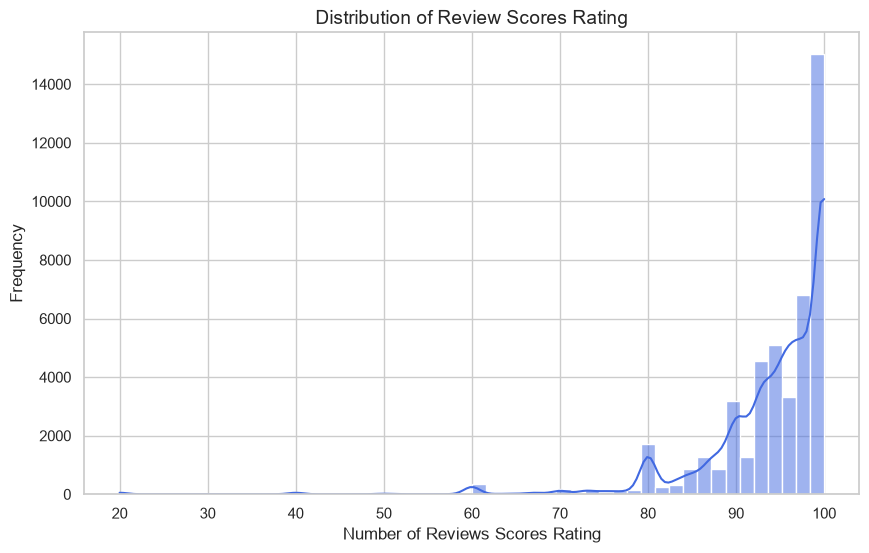

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='review_scores_rating', kde=True, bins=50, color='royalblue')
plt.title('Distribution of Review Scores Rating', fontsize=14)
plt.xlabel('Number of Reviews Scores Rating', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

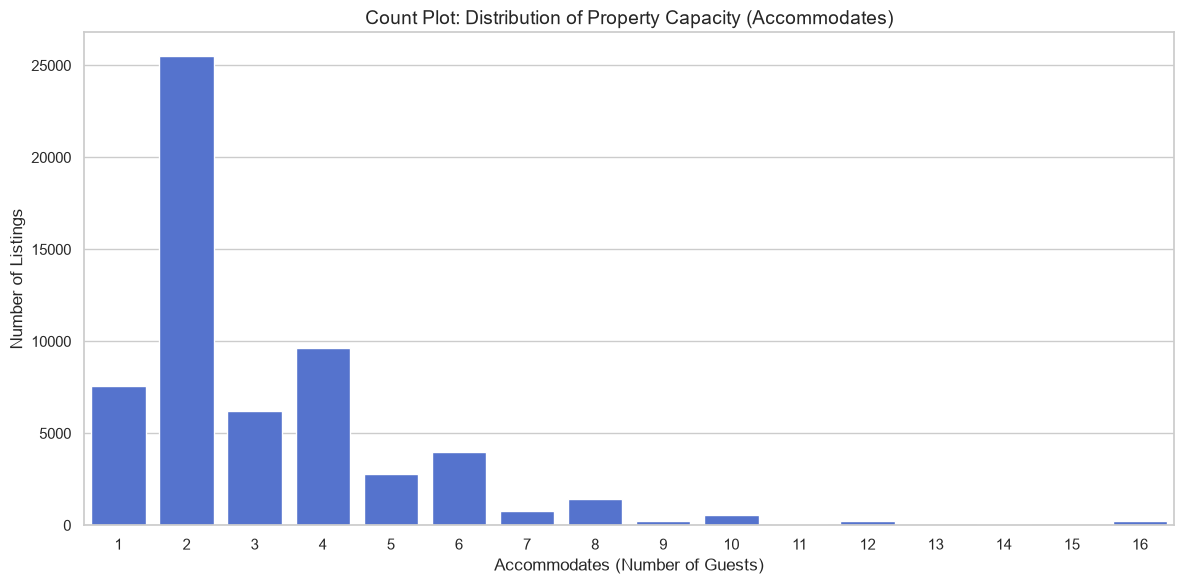

In [11]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='accommodates', color='royalblue')
plt.title('Count Plot: Distribution of Property Capacity (Accommodates)', fontsize=14)
plt.xlabel('Accommodates (Number of Guests)', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.tight_layout()
plt.show()

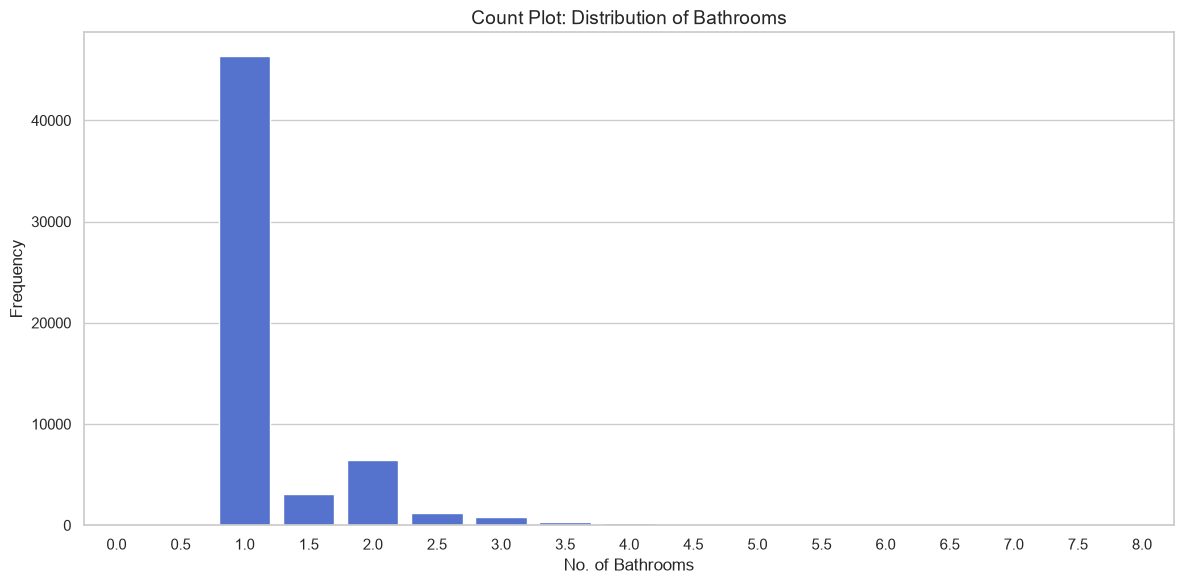

In [12]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='bathrooms', color='royalblue')
plt.title('Count Plot: Distribution of Bathrooms', fontsize=14)
plt.xlabel('No. of Bathrooms', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

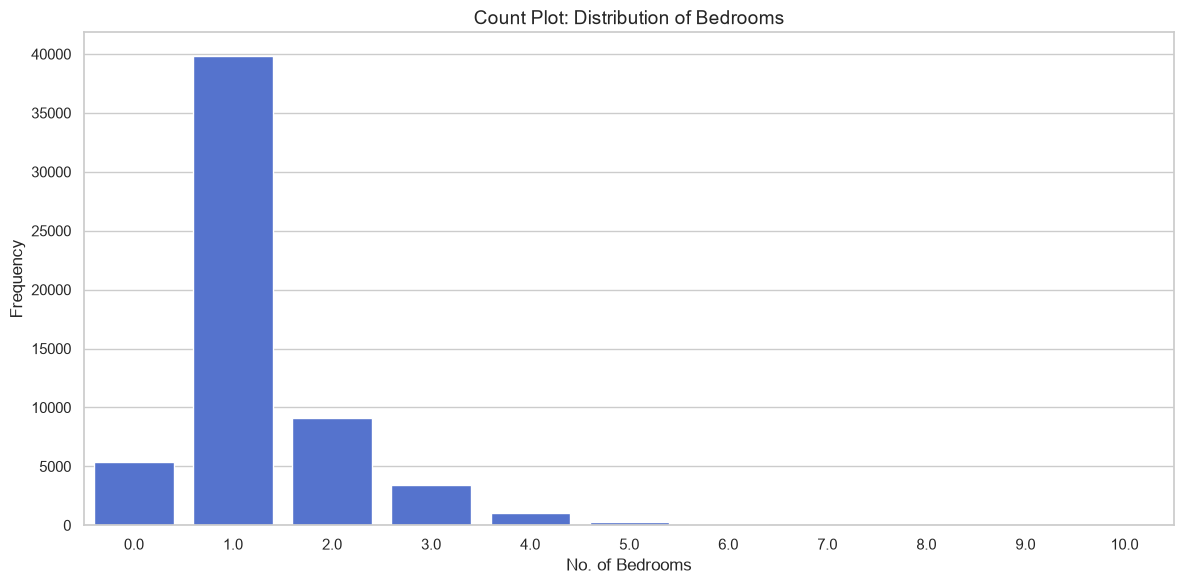

In [13]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='bedrooms', color='royalblue')
plt.title('Count Plot: Distribution of Bedrooms', fontsize=14)
plt.xlabel('No. of Bedrooms', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

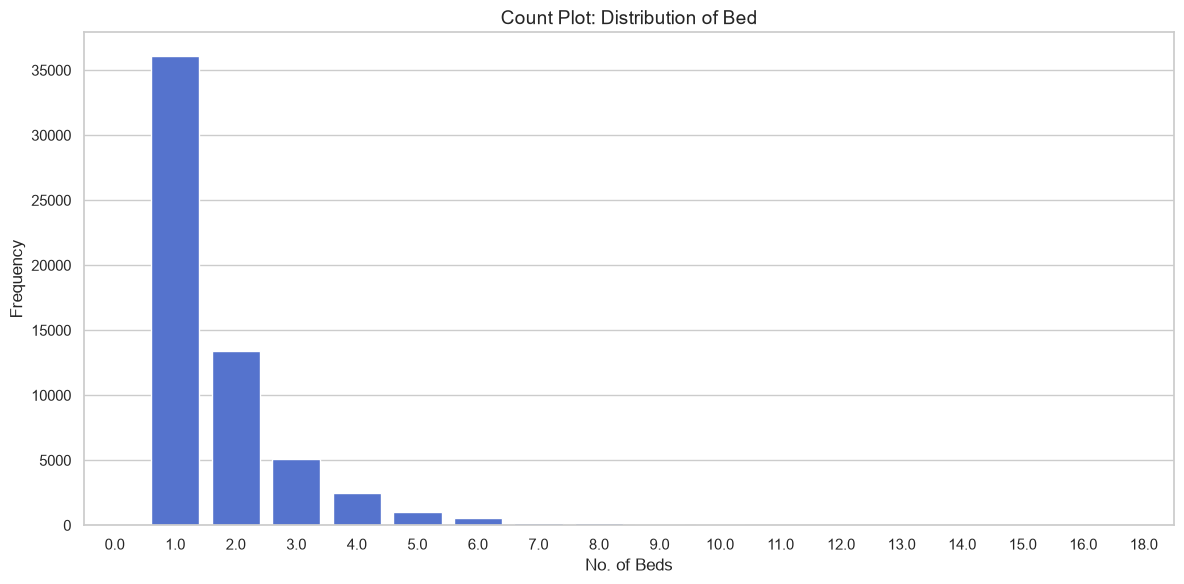

In [14]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='beds', color='royalblue')
plt.title('Count Plot: Distribution of Bed', fontsize=14)
plt.xlabel('No. of Beds', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].mode()[0])
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].mode()[0])
df['beds'] = df['beds'].fillna(df['beds'].mode()[0])

In [16]:
import re

basic_essentials = [
    'Wireless Internet', 'Air conditioning', 'Kitchen', 
    'TV', 'Heating', 'Washer', 'Dryer'
]

premium_essentials = [
    'Free parking on premises', 'Elevator', 'Indoor fireplace', 
    'Pets allowed', 'Self Check-In', '24-hour check-in', 
    'Laptop friendly workspace', 'Hot tub', 'Pool', 'Gym'
]

def clean_amenities(x):
    if pd.isna(x):
        return []
    x = x.replace('{', '').replace('}', '').replace('"', '')
    x = re.sub(r'translation missing:[^,]+', '', x)
    return [a.strip() for a in x.split(',') if a.strip()]
df['amenities_list'] = df['amenities'].apply(clean_amenities)

df['basic_amenities_count'] = df['amenities_list'].apply(
    lambda x: sum(1 for item in x if item in basic_essentials)
)
df['premium_amenities_count'] = df['amenities_list'].apply(
    lambda x: sum(1 for item in x if item in premium_essentials)
)

df = df.drop(columns=['amenities', 'amenities_list'])

print("Structural nulls filled and amenities successfully extracted.")

Structural nulls filled and amenities successfully extracted.


In [17]:
from sklearn.neighbors import KNeighborsClassifier

known_df = df[df['neighbourhood'].notnull()]
unknown_df = df[df['neighbourhood'].isnull()]

X_train = known_df[['latitude', 'longitude']]
y_train = known_df['neighbourhood']

X_test = unknown_df[['latitude', 'longitude']]

knn = KNeighborsClassifier(n_neighbors=5, weights='distance')

knn.fit(X_train, y_train)

predicted_neighbourhoods = knn.predict(X_test)

df.loc[df['neighbourhood'].isnull(), 'neighbourhood'] = predicted_neighbourhoods

print("Successfully imputed missing neighbourhoods using Spatial KNN.")

Successfully imputed missing neighbourhoods using Spatial KNN.


In [18]:
columns_to_drop = ['thumbnail_url', 'first_review', 'last_review', 'zipcode']
df = df.drop(columns=columns_to_drop)

df = df.dropna(subset=['host_has_profile_pic', 'host_identity_verified', 'host_since'])

df['host_response_rate'] = df['host_response_rate'].str.replace('%', '').astype(float)
df['host_response_rate'] = df['host_response_rate'].fillna(df['host_response_rate'].median())

binary_mapping = {'t': 1, 'f': 0}
df['host_has_profile_pic'] = df['host_has_profile_pic'].map(binary_mapping)
df['host_identity_verified'] = df['host_identity_verified'].map(binary_mapping)
df['instant_bookable'] = df['instant_bookable'].map(binary_mapping)

In [19]:
df.shape

(59128, 26)

In [20]:
df.sample(5)

,id,log_price,property_type,room_type,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,bedrooms,beds,basic_amenities_count,premium_amenities_count
25937,7279874,5.273000,House,Entire home/apt,8,1.5,Real Bed,strict,True,Chicago,...,41.884017,-87.693115,AFFORDABLE HISTORIC 3 bedCHICAGO ROW (entire)H...,Garfield Park,36,95.0,3.0,5.0,6,3
13114,626136,3.891820,Apartment,Private room,1,1.0,Real Bed,strict,True,NYC,...,40.678889,-73.948096,Cute room in huge artist loft!,Bedford-Stuyvesant,7,97.0,1.0,1.0,4,0
42570,8106026,6.652863,House,Entire home/apt,6,3.0,Real Bed,strict,False,LA,...,33.977391,-118.463912,Marina del rey beach house,Marina Del Rey,5,100.0,3.0,3.0,7,4
36319,20469300,3.951244,Apartment,Private room,2,1.0,Real Bed,strict,True,NYC,...,40.690510,-73.958446,"Private Room in Spacious, Bohemian Loft",Clinton Hill,5,80.0,1.0,1.0,7,3
46815,4645274,4.248495,House,Private room,2,2.5,Futon,moderate,True,Boston,...,42.312548,-71.062273,"Eagle Sea view,15min metro ride to center,safe...",Dorchester,48,93.0,1.0,1.0,6,3


In [21]:
df.isnull().sum()

id                             0
log_price                      0
property_type                  0
room_type                      0
accommodates                   0
bathrooms                      0
bed_type                       0
cancellation_policy            0
cleaning_fee                   0
city                           0
description                    0
host_has_profile_pic           0
host_identity_verified         0
host_response_rate             0
host_since                     0
instant_bookable               0
latitude                       0
longitude                      0
name                           0
neighbourhood                  0
number_of_reviews              0
review_scores_rating       13356
bedrooms                       0
beds                           0
basic_amenities_count          0
premium_amenities_count        0
dtype: int64

In [22]:
df_pricing = df.copy()

df_pricing['has_reviews'] = (df_pricing['number_of_reviews'] > 0).astype(int)
df_pricing['review_scores_rating'] = df_pricing['review_scores_rating'].fillna(df_pricing['review_scores_rating'].median())

columns_to_drop_for_ml = ['name', 'description', 'host_since', 'neighbourhood']
df_pricing = df_pricing.drop(columns=columns_to_drop_for_ml)

df_pricing = pd.get_dummies(df_pricing, columns=['room_type', 'property_type', 'cancellation_policy', 'city'], drop_first=True)

df_ratings = df.copy()

df_ratings = df_ratings.dropna(subset=['review_scores_rating'])
df_ratings = df_ratings[df_ratings['number_of_reviews'] >= 3]

df_pricing.to_csv('cleaned_data_pricing.csv', index=False)
df_ratings.to_csv('cleaned_data_ratings.csv', index=False)

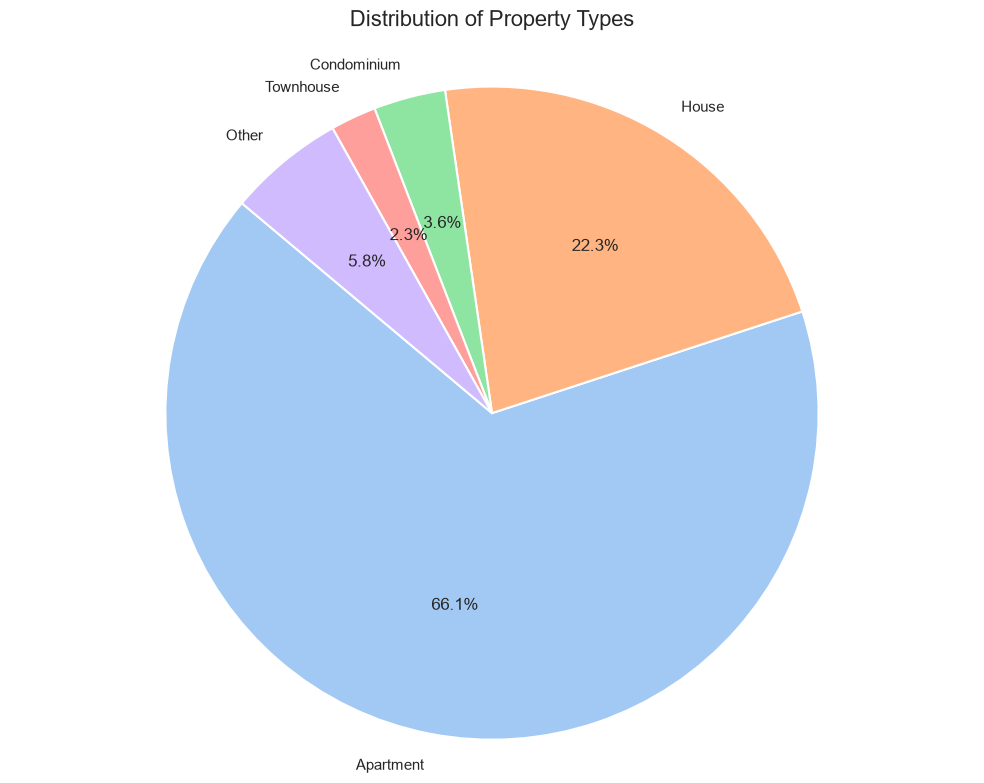

In [23]:
prop_counts = df['property_type'].value_counts()
top_props = prop_counts[:4]
other_props = pd.Series({'Other': prop_counts[4:].sum()})
plot_data = pd.concat([top_props, other_props])
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))
colors = sns.color_palette("pastel")[0:len(plot_data)]
plt.pie(plot_data, 
        labels=plot_data.index, 
        autopct='%1.1f%%',       
        startangle=140,          
        colors=colors, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}) 

plt.title('Distribution of Property Types', fontsize=16, pad=20)
plt.axis('equal') 
plt.tight_layout()
plt.show()

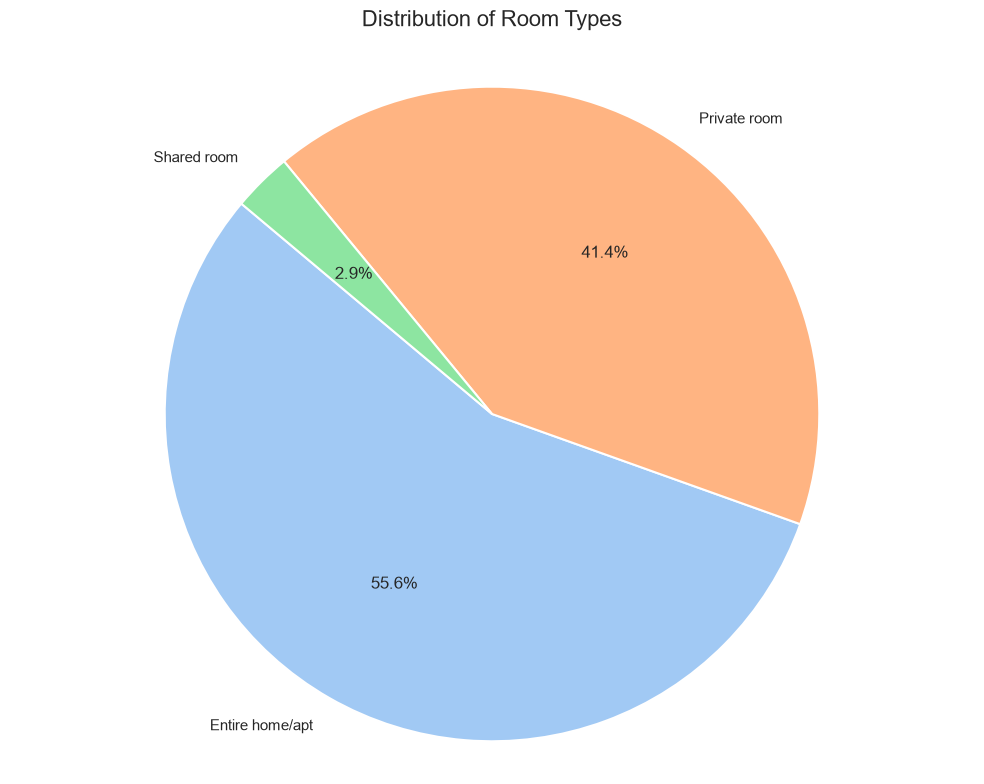

In [24]:
room_counts = df['room_type'].value_counts()
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))
colors = sns.color_palette("pastel")[0:len(room_counts)]
plt.pie(room_counts, 
        labels=room_counts.index, 
        autopct='%1.1f%%',       
        startangle=140,          
        colors=colors, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}) 
plt.title('Distribution of Room Types', fontsize=16, pad=20)
plt.axis('equal') 
plt.tight_layout()
plt.show()

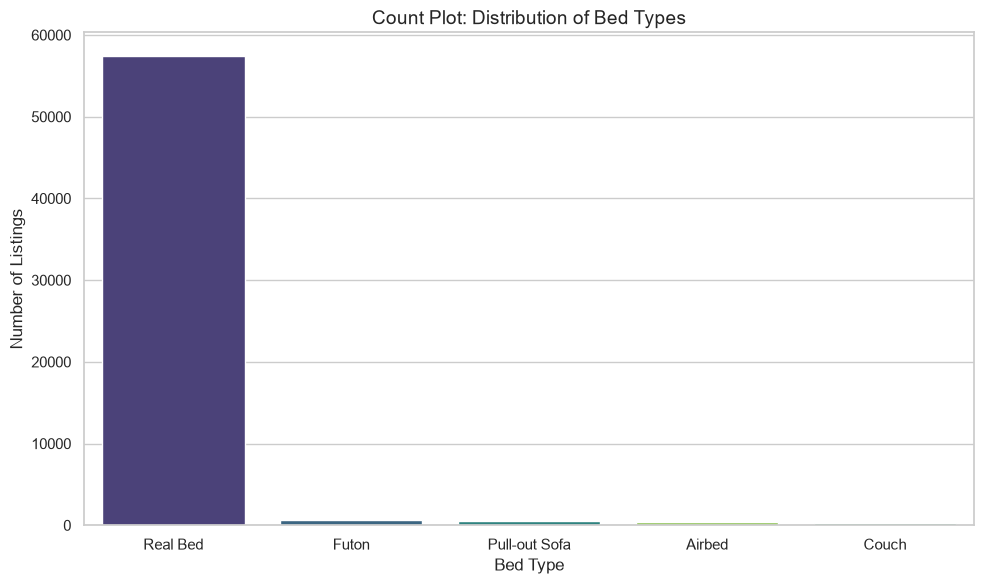

In [25]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df, 
    x='bed_type', 
    hue='bed_type', 
    palette='viridis', 
    order=df['bed_type'].value_counts().index,
    legend=False
)
plt.title('Count Plot: Distribution of Bed Types', fontsize=14)
plt.xlabel('Bed Type', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.tight_layout()
plt.show()

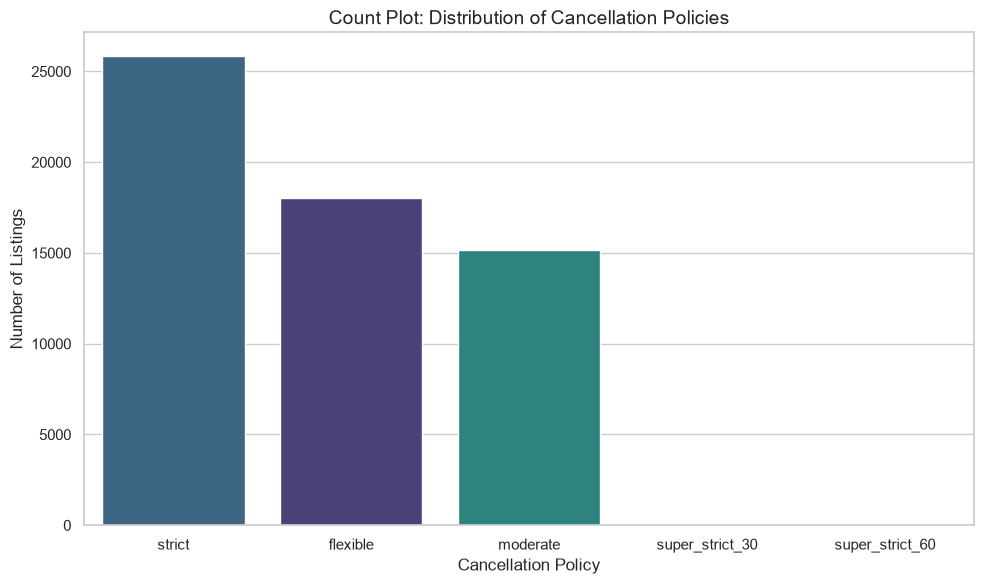

In [26]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
ax1 = sns.countplot(
    data=df, 
    x='cancellation_policy', 
    hue='cancellation_policy', 
    palette='viridis', 
    order=df['cancellation_policy'].value_counts().index
)
if ax1.get_legend() is not None:
    ax1.get_legend().remove()
plt.title('Count Plot: Distribution of Cancellation Policies', fontsize=14)
plt.xlabel('Cancellation Policy', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.tight_layout()
plt.show()

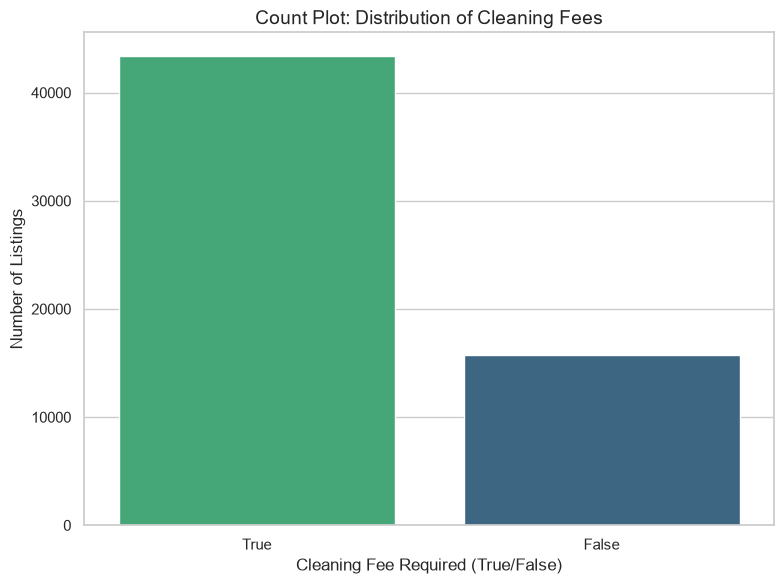

In [27]:
plt.figure(figsize=(8, 6))
ax2 = sns.countplot(
    data=df, 
    x='cleaning_fee', 
    hue='cleaning_fee', 
    palette='viridis', 
    order=df['cleaning_fee'].value_counts().index
)
if ax2.get_legend() is not None:
    ax2.get_legend().remove()
plt.title('Count Plot: Distribution of Cleaning Fees', fontsize=14)
plt.xlabel('Cleaning Fee Required (True/False)', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.tight_layout()
plt.show()

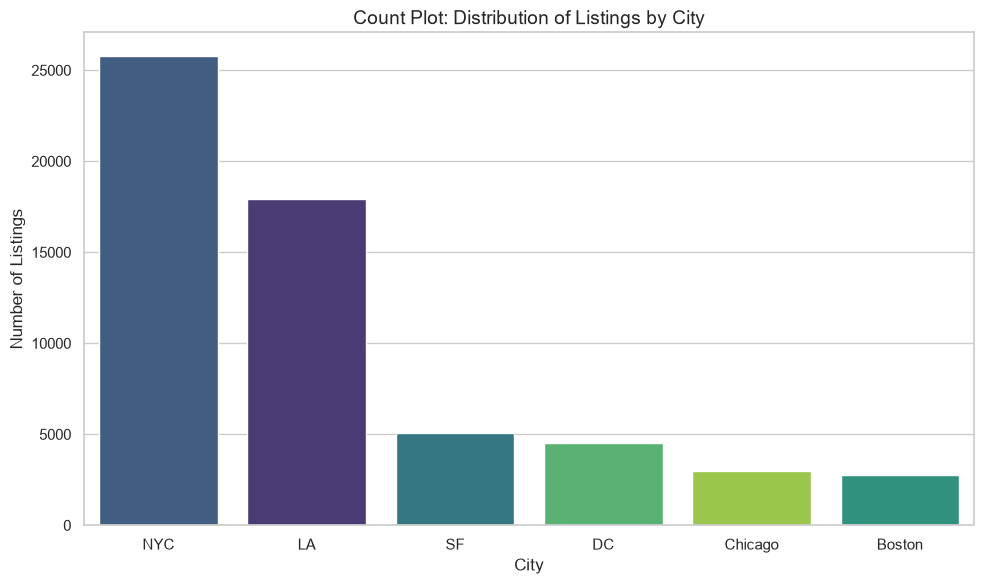

In [28]:
plt.figure(figsize=(10, 6))
ax1 = sns.countplot(
    data=df, 
    x='city', 
    hue='city', 
    palette='viridis', 
    order=df['city'].value_counts().index
)
if ax1.get_legend() is not None:
    ax1.get_legend().remove()
plt.title('Count Plot: Distribution of Listings by City', fontsize=14)
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.tight_layout()
plt.show()

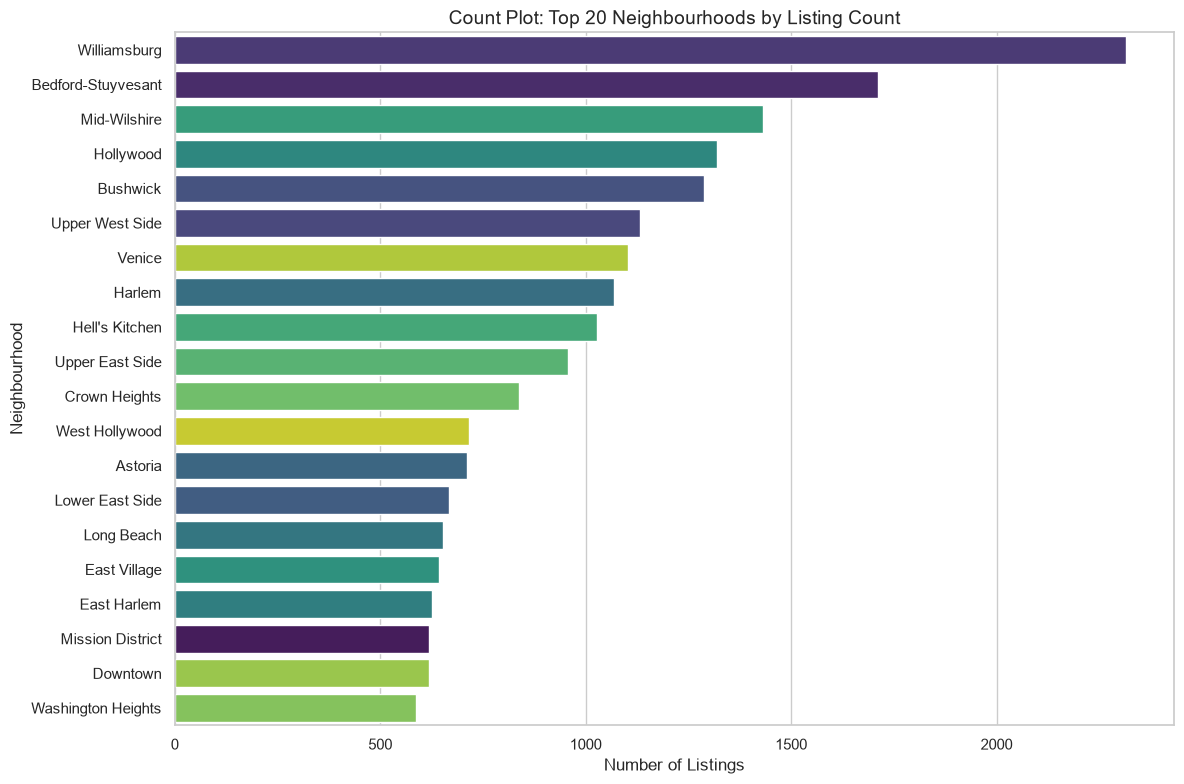

In [29]:
plt.figure(figsize=(12, 8))
top_neighbourhoods = df['neighbourhood'].value_counts().nlargest(20).index
df_top_neigh = df[df['neighbourhood'].isin(top_neighbourhoods)]
ax2 = sns.countplot(
    data=df_top_neigh, 
    y='neighbourhood', 
    hue='neighbourhood', 
    palette='viridis', 
    order=top_neighbourhoods
)
if ax2.get_legend() is not None:
    ax2.get_legend().remove()
plt.title('Count Plot: Top 20 Neighbourhoods by Listing Count', fontsize=14)
plt.xlabel('Number of Listings', fontsize=12)
plt.ylabel('Neighbourhood', fontsize=12)
plt.tight_layout()
plt.show()

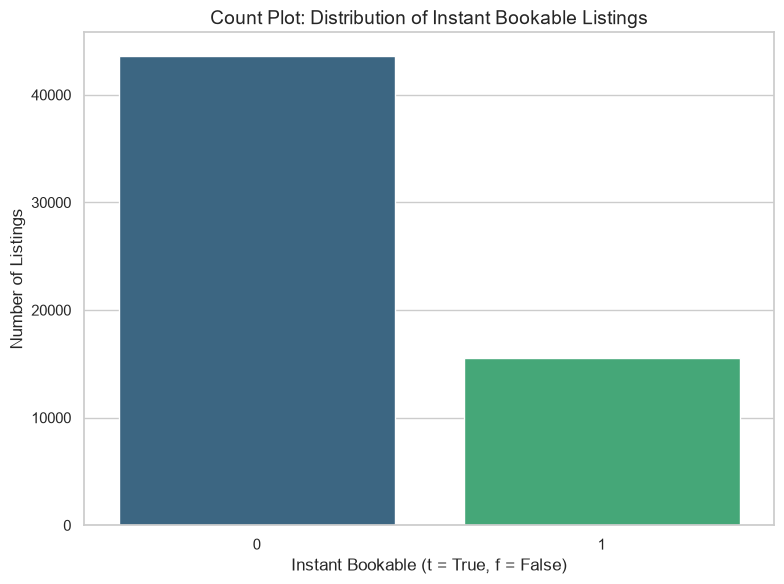

In [30]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=df, 
    x='instant_bookable', 
    hue='instant_bookable', 
    palette='viridis', 
    order=df['instant_bookable'].value_counts().index
)
if ax.get_legend() is not None:
    ax.get_legend().remove()
plt.title('Count Plot: Distribution of Instant Bookable Listings', fontsize=14)
plt.xlabel('Instant Bookable (t = True, f = False)', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.tight_layout()
plt.show()

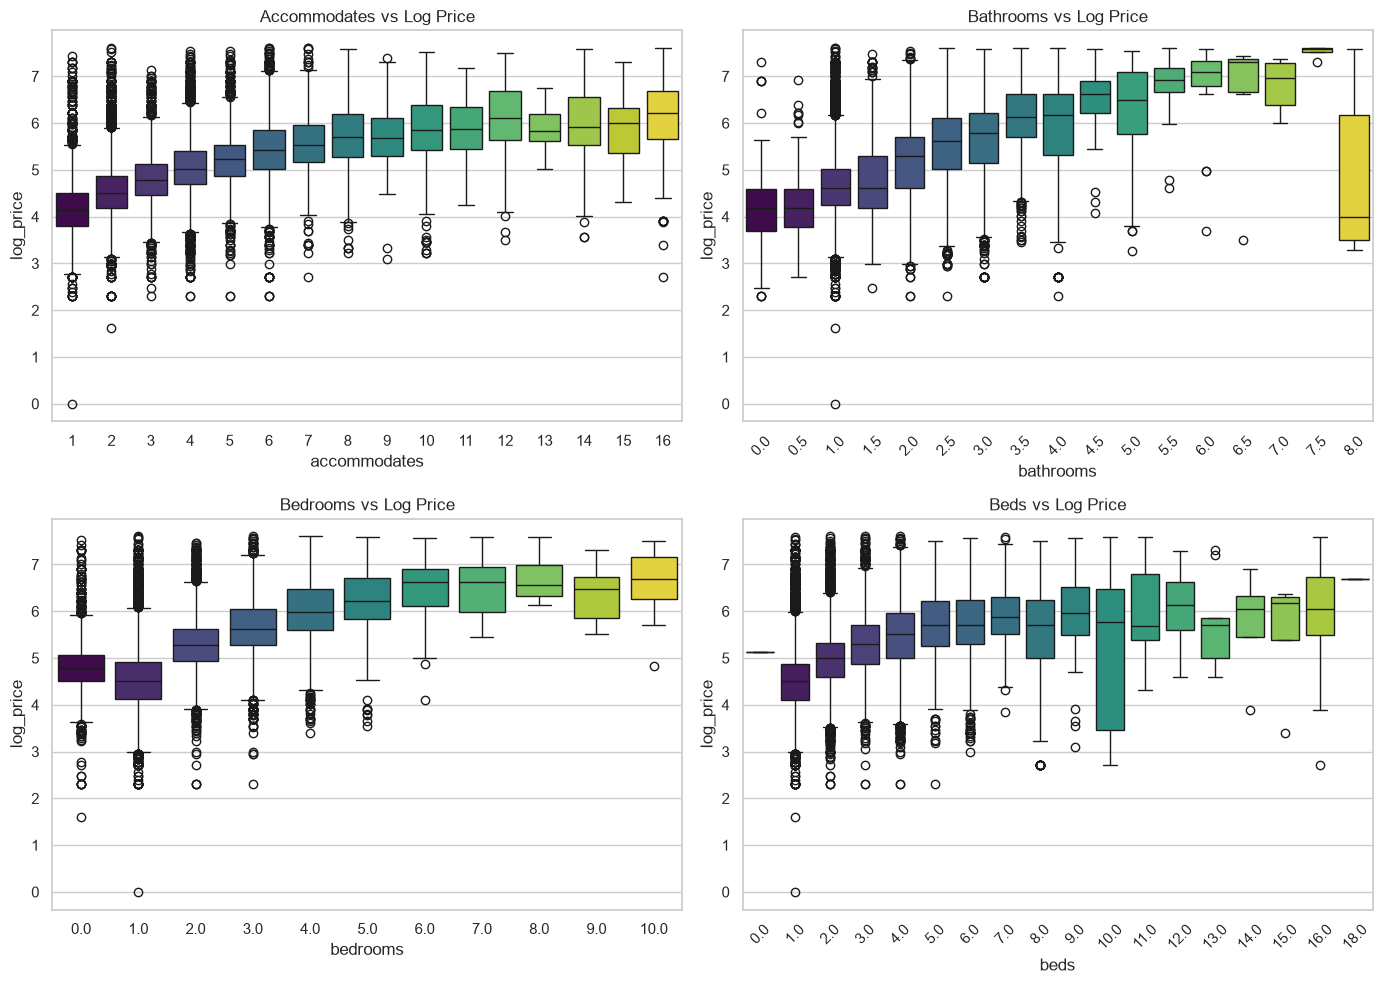

In [31]:
def remove_legend(ax):
    if ax.get_legend() is not None:
        ax.get_legend().remove()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='accommodates', y='log_price', ax=axes[0,0], hue='accommodates', palette='viridis')
remove_legend(axes[0,0])
axes[0,0].set_title('Accommodates vs Log Price')

sns.boxplot(data=df, x='bathrooms', y='log_price', ax=axes[0,1], hue='bathrooms', palette='viridis')
remove_legend(axes[0,1])
axes[0,1].set_title('Bathrooms vs Log Price')
axes[0,1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='bedrooms', y='log_price', ax=axes[1,0], hue='bedrooms', palette='viridis')
remove_legend(axes[1,0])
axes[1,0].set_title('Bedrooms vs Log Price')

sns.boxplot(data=df, x='beds', y='log_price', ax=axes[1,1], hue='beds', palette='viridis')
remove_legend(axes[1,1])
axes[1,1].set_title('Beds vs Log Price')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

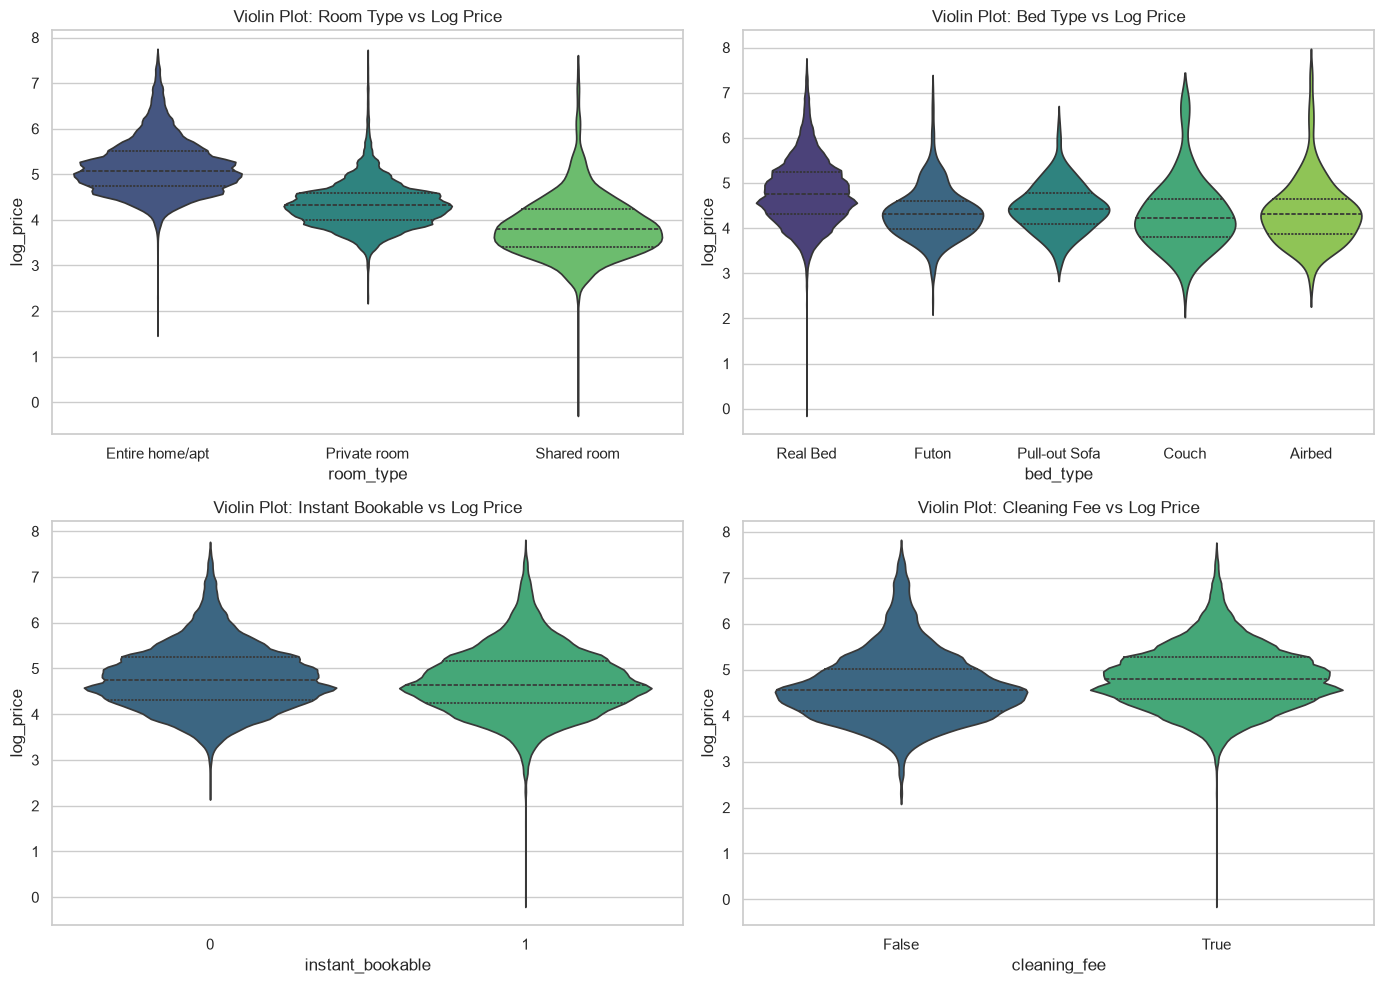

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.violinplot(data=df, x='room_type', y='log_price', ax=axes[0,0], hue='room_type', palette='viridis', inner='quartile')
remove_legend(axes[0,0])
axes[0,0].set_title('Violin Plot: Room Type vs Log Price', fontsize=12)
sns.violinplot(data=df, x='bed_type', y='log_price', ax=axes[0,1], hue='bed_type', palette='viridis', inner='quartile')
remove_legend(axes[0,1])
axes[0,1].set_title('Violin Plot: Bed Type vs Log Price', fontsize=12)
sns.violinplot(data=df, x='instant_bookable', y='log_price', ax=axes[1,0], hue='instant_bookable', palette='viridis', inner='quartile')
remove_legend(axes[1,0])
axes[1,0].set_title('Violin Plot: Instant Bookable vs Log Price', fontsize=12)
sns.violinplot(data=df, x='cleaning_fee', y='log_price', ax=axes[1,1], hue='cleaning_fee', palette='viridis', inner='quartile')
remove_legend(axes[1,1])
axes[1,1].set_title('Violin Plot: Cleaning Fee vs Log Price', fontsize=12)
plt.tight_layout()
plt.show()

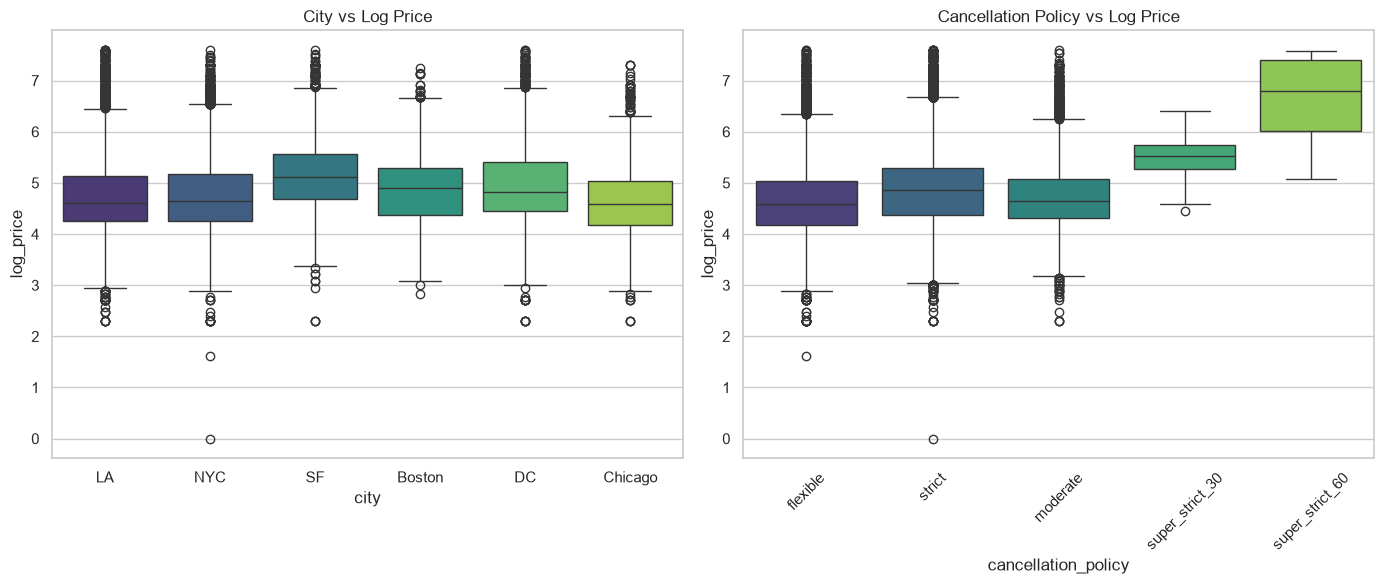

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='city', y='log_price', ax=axes[0], hue='city', palette='viridis')
remove_legend(axes[0])
axes[0].set_title('City vs Log Price')

sns.boxplot(data=df, x='cancellation_policy', y='log_price', ax=axes[1], hue='cancellation_policy', palette='viridis')
remove_legend(axes[1])
axes[1].set_title('Cancellation Policy vs Log Price')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

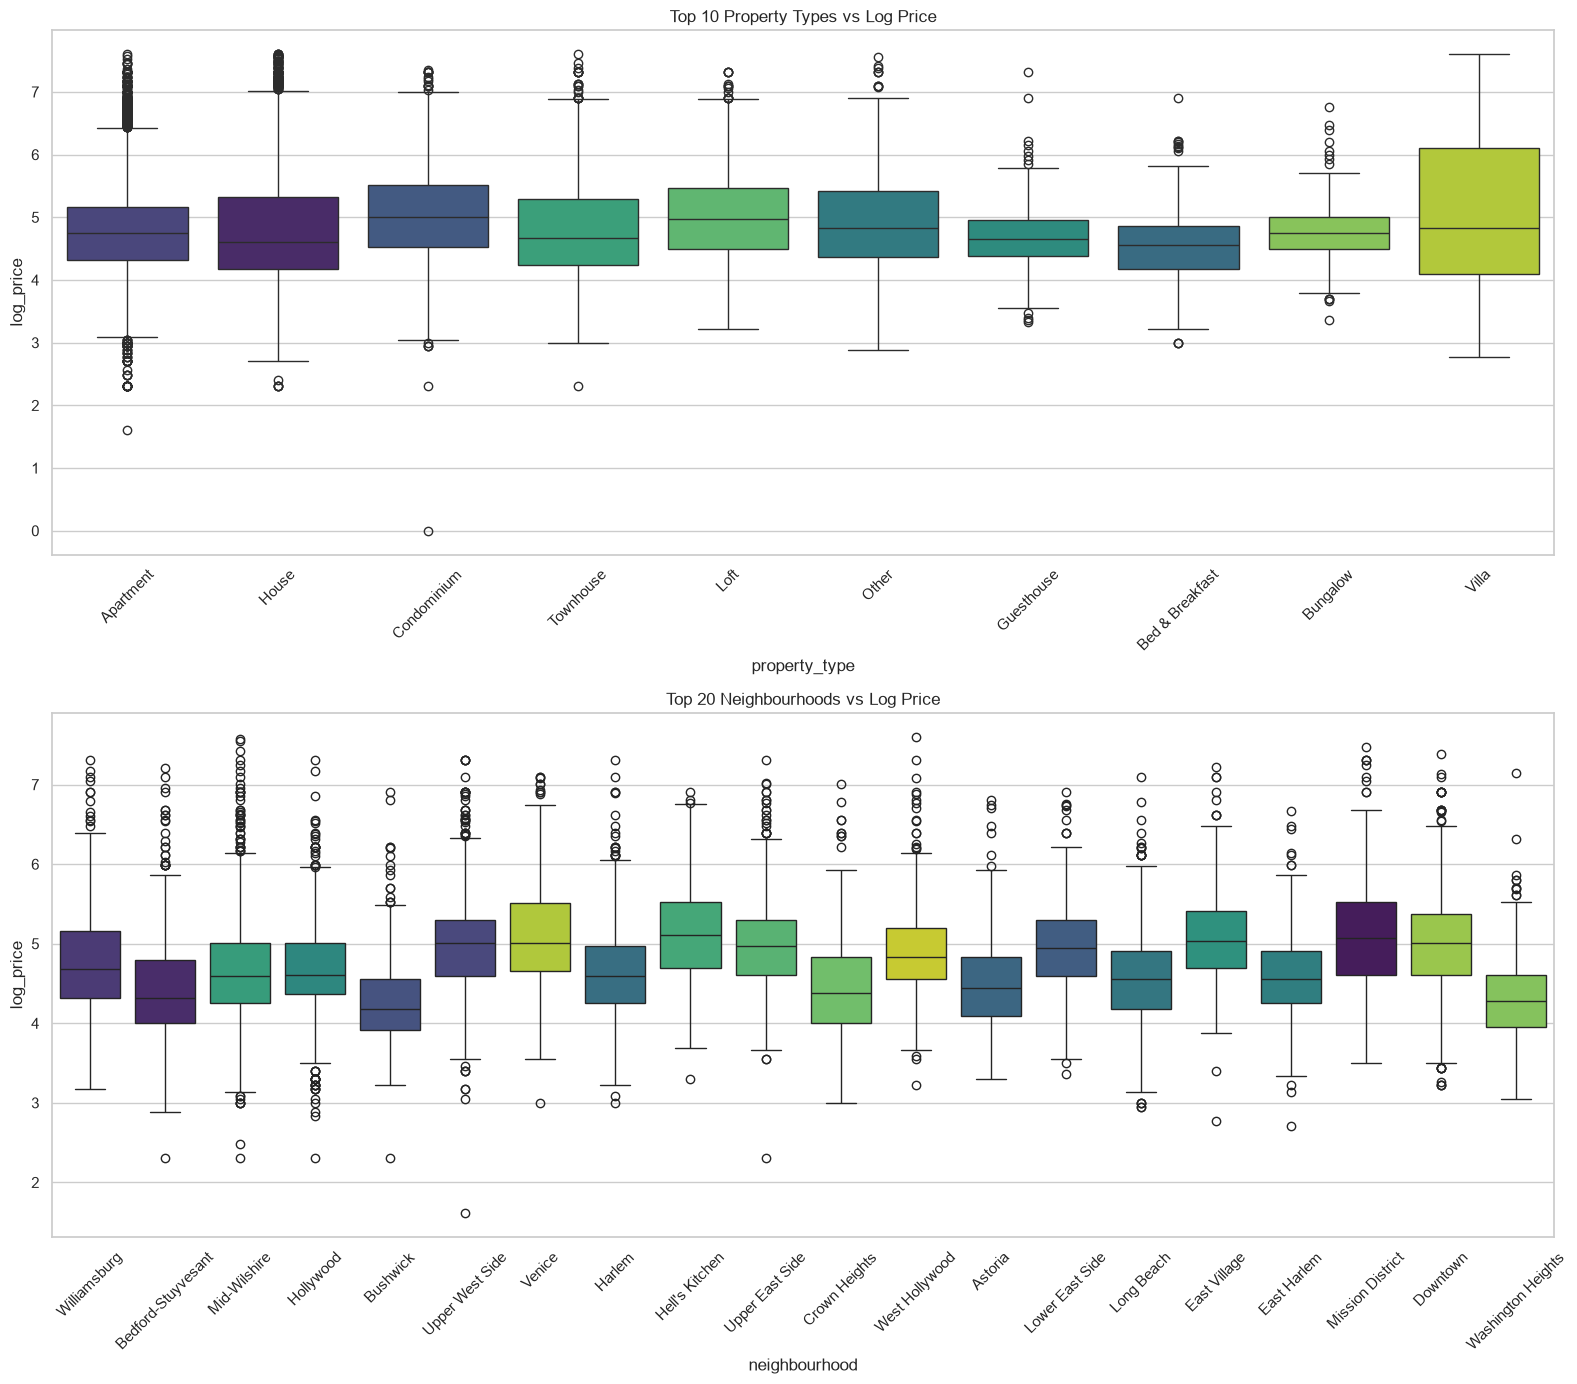

In [34]:
top_properties = df['property_type'].value_counts().nlargest(10).index
top_neighbourhoods = df['neighbourhood'].value_counts().nlargest(20).index

fig, axes = plt.subplots(2, 1, figsize=(16, 14))

sns.boxplot(
    data=df[df['property_type'].isin(top_properties)], 
    x='property_type', y='log_price', ax=axes[0], 
    hue='property_type', palette='viridis', order=top_properties
)
remove_legend(axes[0])
axes[0].set_title('Top 10 Property Types vs Log Price')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(
    data=df[df['neighbourhood'].isin(top_neighbourhoods)], 
    x='neighbourhood', y='log_price', ax=axes[1], 
    hue='neighbourhood', palette='viridis', order=top_neighbourhoods
)
remove_legend(axes[1])
axes[1].set_title('Top 20 Neighbourhoods vs Log Price')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

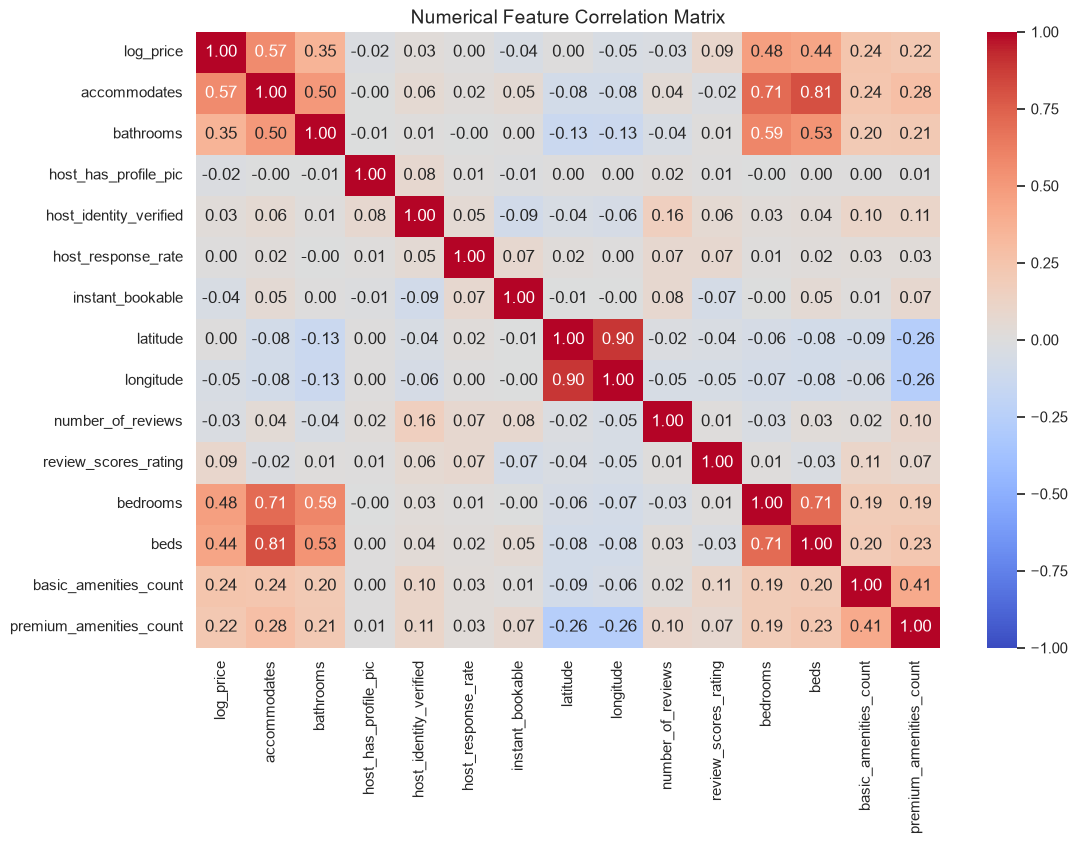

In [35]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
if 'id' in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=['id'])
    
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title('Numerical Feature Correlation Matrix', fontsize=14)
plt.show()

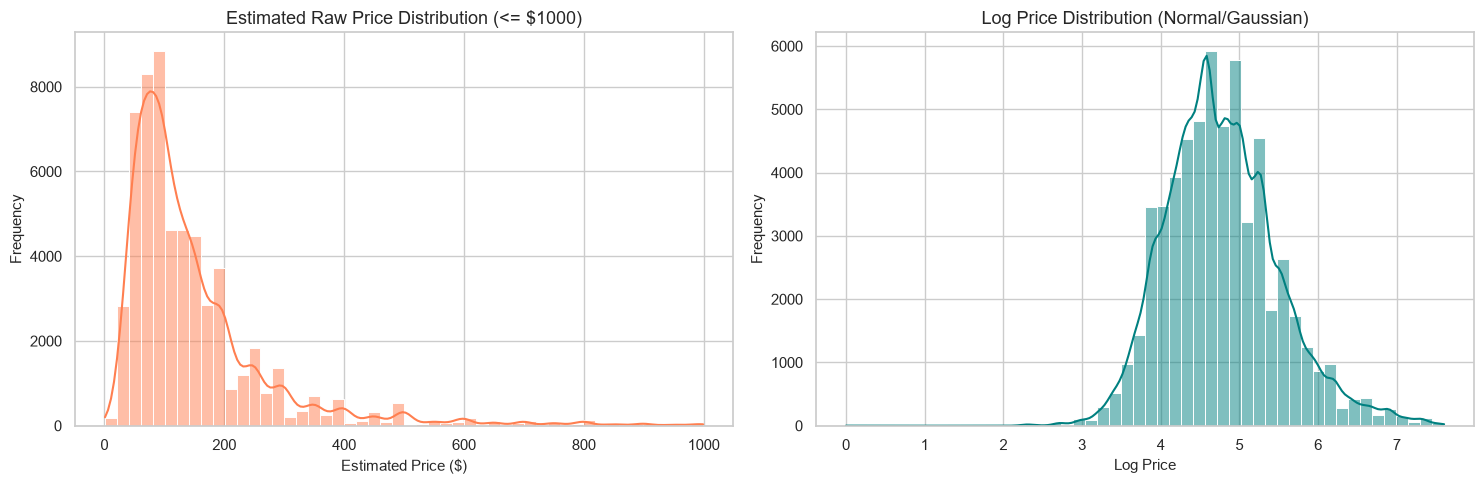

In [36]:
df['estimated_raw_price'] = np.exp(df['log_price'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df[df['estimated_raw_price'] <= 1000]['estimated_raw_price'], bins=50, kde=True, ax=axes[0], color='coral')
axes[0].set_title('Estimated Raw Price Distribution (<= $1000)', fontsize=13)
axes[0].set_xlabel('Estimated Price ($)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)

sns.histplot(df['log_price'], bins=50, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Log Price Distribution (Normal/Gaussian)', fontsize=13)
axes[1].set_xlabel('Log Price', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)

plt.tight_layout()
plt.show()

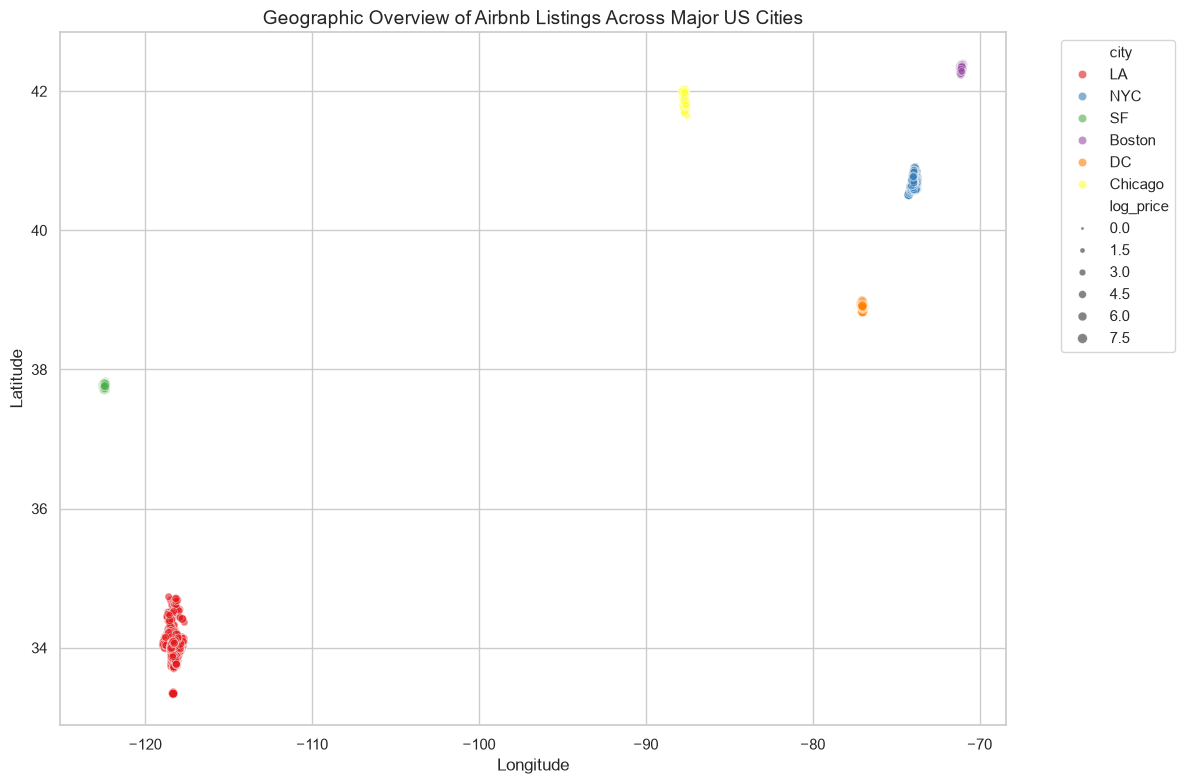

In [37]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='city',           # Grouping by city instead of neighbourhood
    size='log_price',     # Using the pre-transformed log_price
    sizes=(5, 50),        # Scaled down slightly since there are 74,000+ points
    alpha=0.6,
    palette='Set1'
)

plt.title("Geographic Overview of Airbnb Listings Across Major US Cities", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Move legend outside the plot so it doesn't cover data points
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

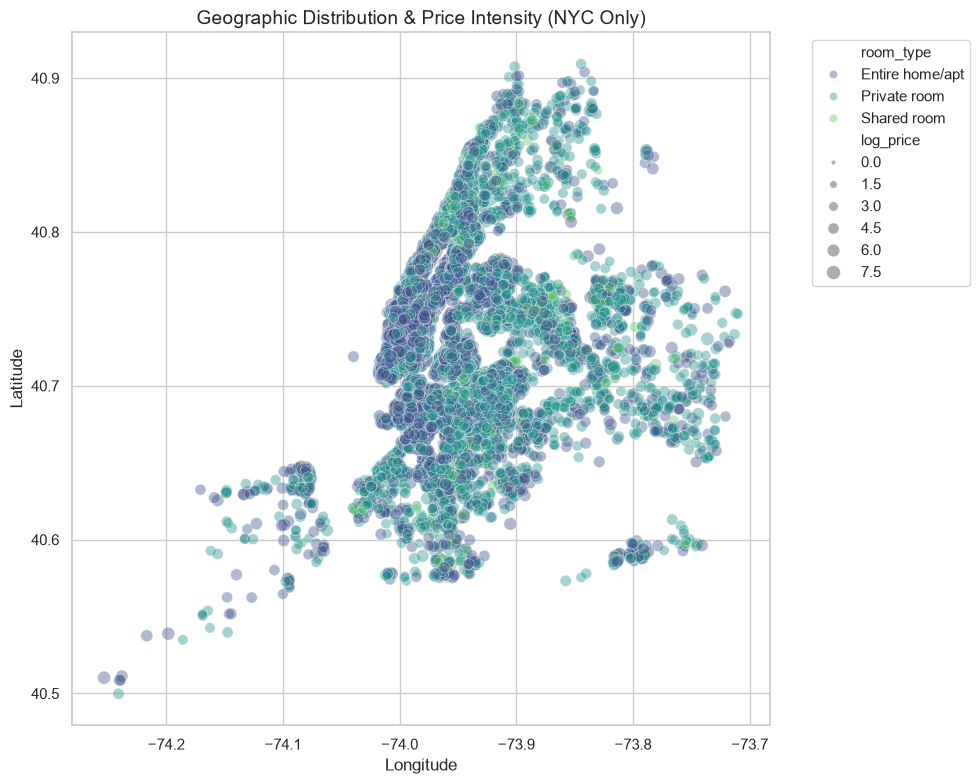

In [38]:
df_nyc = df[df['city'] == 'NYC']

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df_nyc,
    x='longitude',
    y='latitude',
    hue='room_type',      # Coloring by room type 
    size='log_price',     # Sizing by log_price
    sizes=(10, 100),
    alpha=0.4,
    palette='viridis'
)

plt.title("Geographic Distribution & Price Intensity (NYC Only)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\saish\AppData\Local\Temp\ipykernel_31540\3987660432.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


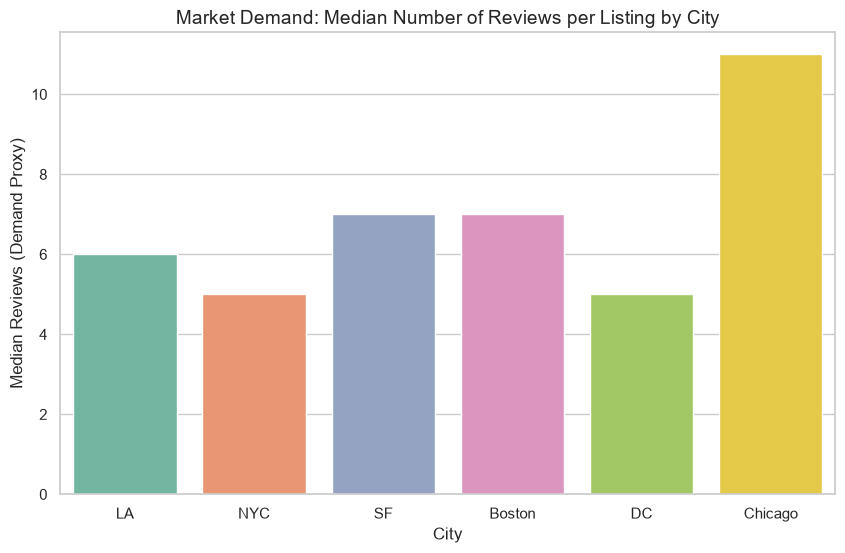

In [39]:
plt.figure(figsize=(10, 6))

# Calculate total reviews (proxy for total bookings/demand) per city
# We use sum to see market size, or median to see average listing performance. Let's look at average performance.
sns.barplot(
    data=df, 
    x='city', 
    y='number_of_reviews', 
    estimator=np.median, 
    palette='Set2',
    errorbar=None
)

plt.title('Market Demand: Median Number of Reviews per Listing by City', fontsize=14)
plt.xlabel('City', fontsize=12)
plt.ylabel('Median Reviews (Demand Proxy)', fontsize=12)
plt.show()

C:\Users\saish\AppData\Local\Temp\ipykernel_31540\292313854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


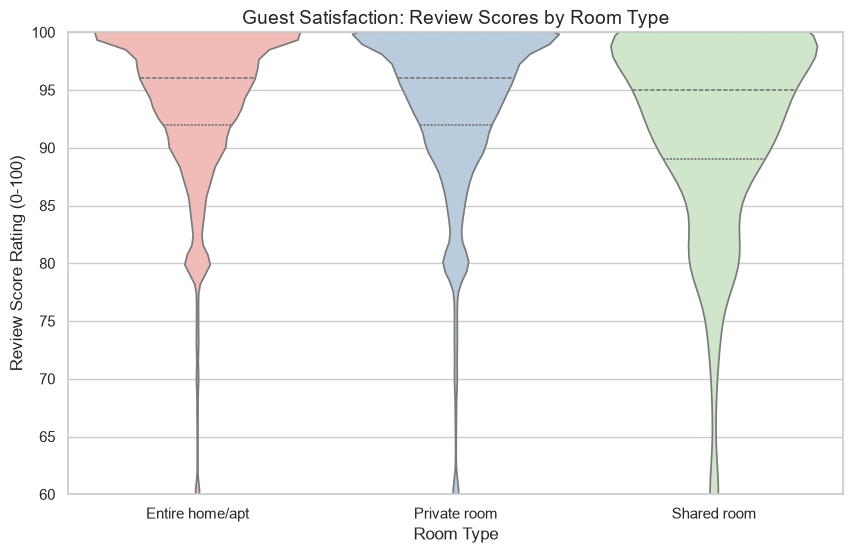

In [40]:
plt.figure(figsize=(10, 6))

# Drop NaNs just for this visualization
df_ratings = df.dropna(subset=['review_scores_rating'])

sns.violinplot(
    data=df_ratings, 
    x='room_type', 
    y='review_scores_rating', 
    palette='Pastel1',
    inner='quartile'
)

plt.title('Guest Satisfaction: Review Scores by Room Type', fontsize=14)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Review Score Rating (0-100)', fontsize=12)

# Cap the Y-axis to focus on the bulk of the data (Airbnb ratings are rarely below 60)
plt.ylim(60, 100) 
plt.show()

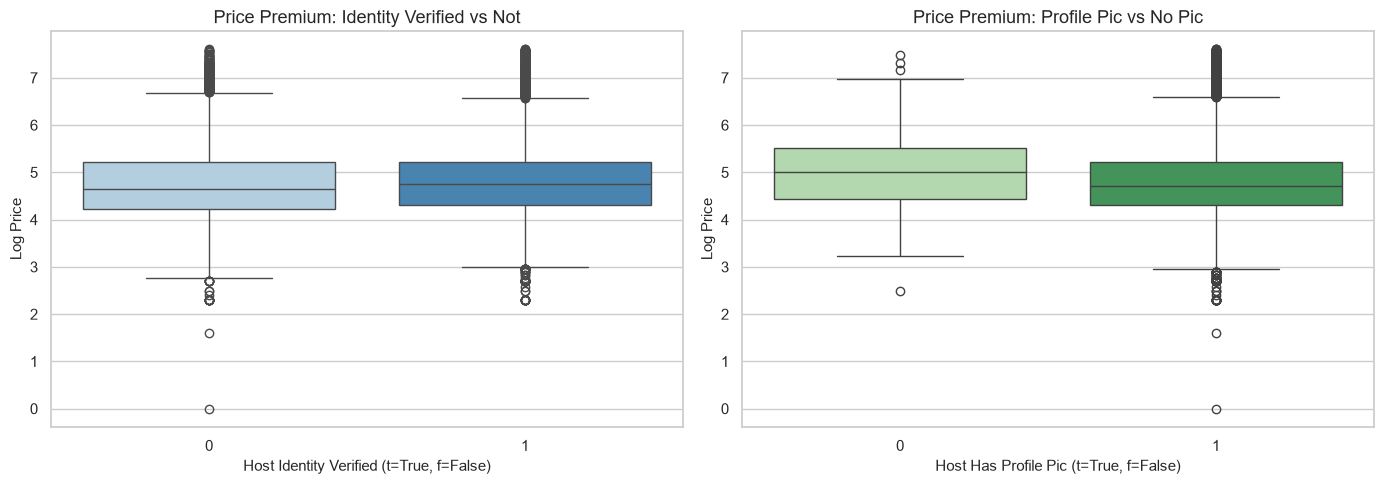

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Identity Verified
sns.boxplot(
    data=df, 
    x='host_identity_verified', 
    y='log_price', 
    hue='host_identity_verified',  # Added hue
    palette='Blues', 
    legend=False,                  # Hid the redundant legend
    ax=axes[0]
)
axes[0].set_title('Price Premium: Identity Verified vs Not', fontsize=13)
axes[0].set_xlabel('Host Identity Verified (t=True, f=False)', fontsize=11)
axes[0].set_ylabel('Log Price', fontsize=11)

# Plot 2: Profile Picture
sns.boxplot(
    data=df, 
    x='host_has_profile_pic', 
    y='log_price', 
    hue='host_has_profile_pic',    # Added hue
    palette='Greens', 
    legend=False,                  # Hid the redundant legend
    ax=axes[1]
)
axes[1].set_title('Price Premium: Profile Pic vs No Pic', fontsize=13)
axes[1].set_xlabel('Host Has Profile Pic (t=True, f=False)', fontsize=11)
axes[1].set_ylabel('Log Price', fontsize=11)

plt.tight_layout()
plt.show()

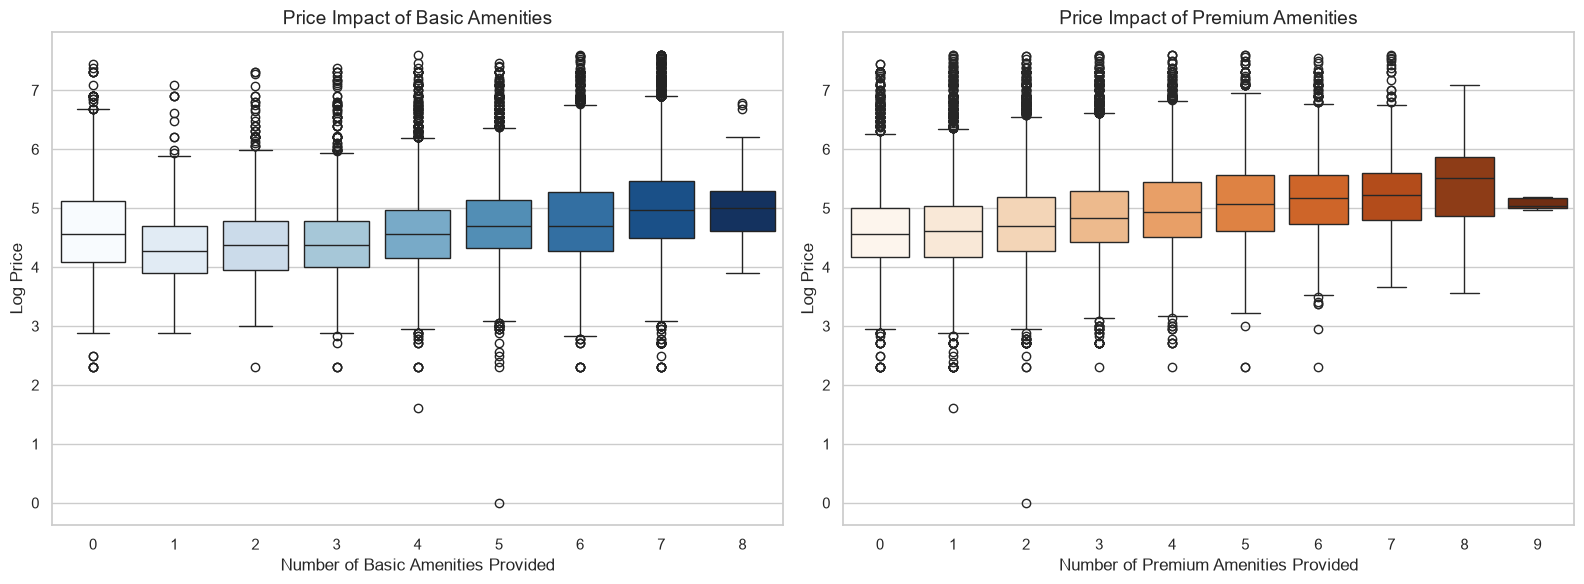

In [42]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Basic Amenities
sns.boxplot(
    data=df, 
    x='basic_amenities_count', 
    y='log_price', 
    hue='basic_amenities_count', 
    palette='Blues', 
    legend=False, 
    ax=axes[0]
)
axes[0].set_title('Price Impact of Basic Amenities', fontsize=14)
axes[0].set_xlabel('Number of Basic Amenities Provided', fontsize=12)
axes[0].set_ylabel('Log Price', fontsize=12)

# Plot 2: Premium Amenities
sns.boxplot(
    data=df, 
    x='premium_amenities_count', 
    y='log_price', 
    hue='premium_amenities_count', 
    palette='Oranges', 
    legend=False, 
    ax=axes[1]
)
axes[1].set_title('Price Impact of Premium Amenities', fontsize=14)
axes[1].set_xlabel('Number of Premium Amenities Provided', fontsize=12)
axes[1].set_ylabel('Log Price', fontsize=12)

plt.tight_layout()
plt.show()

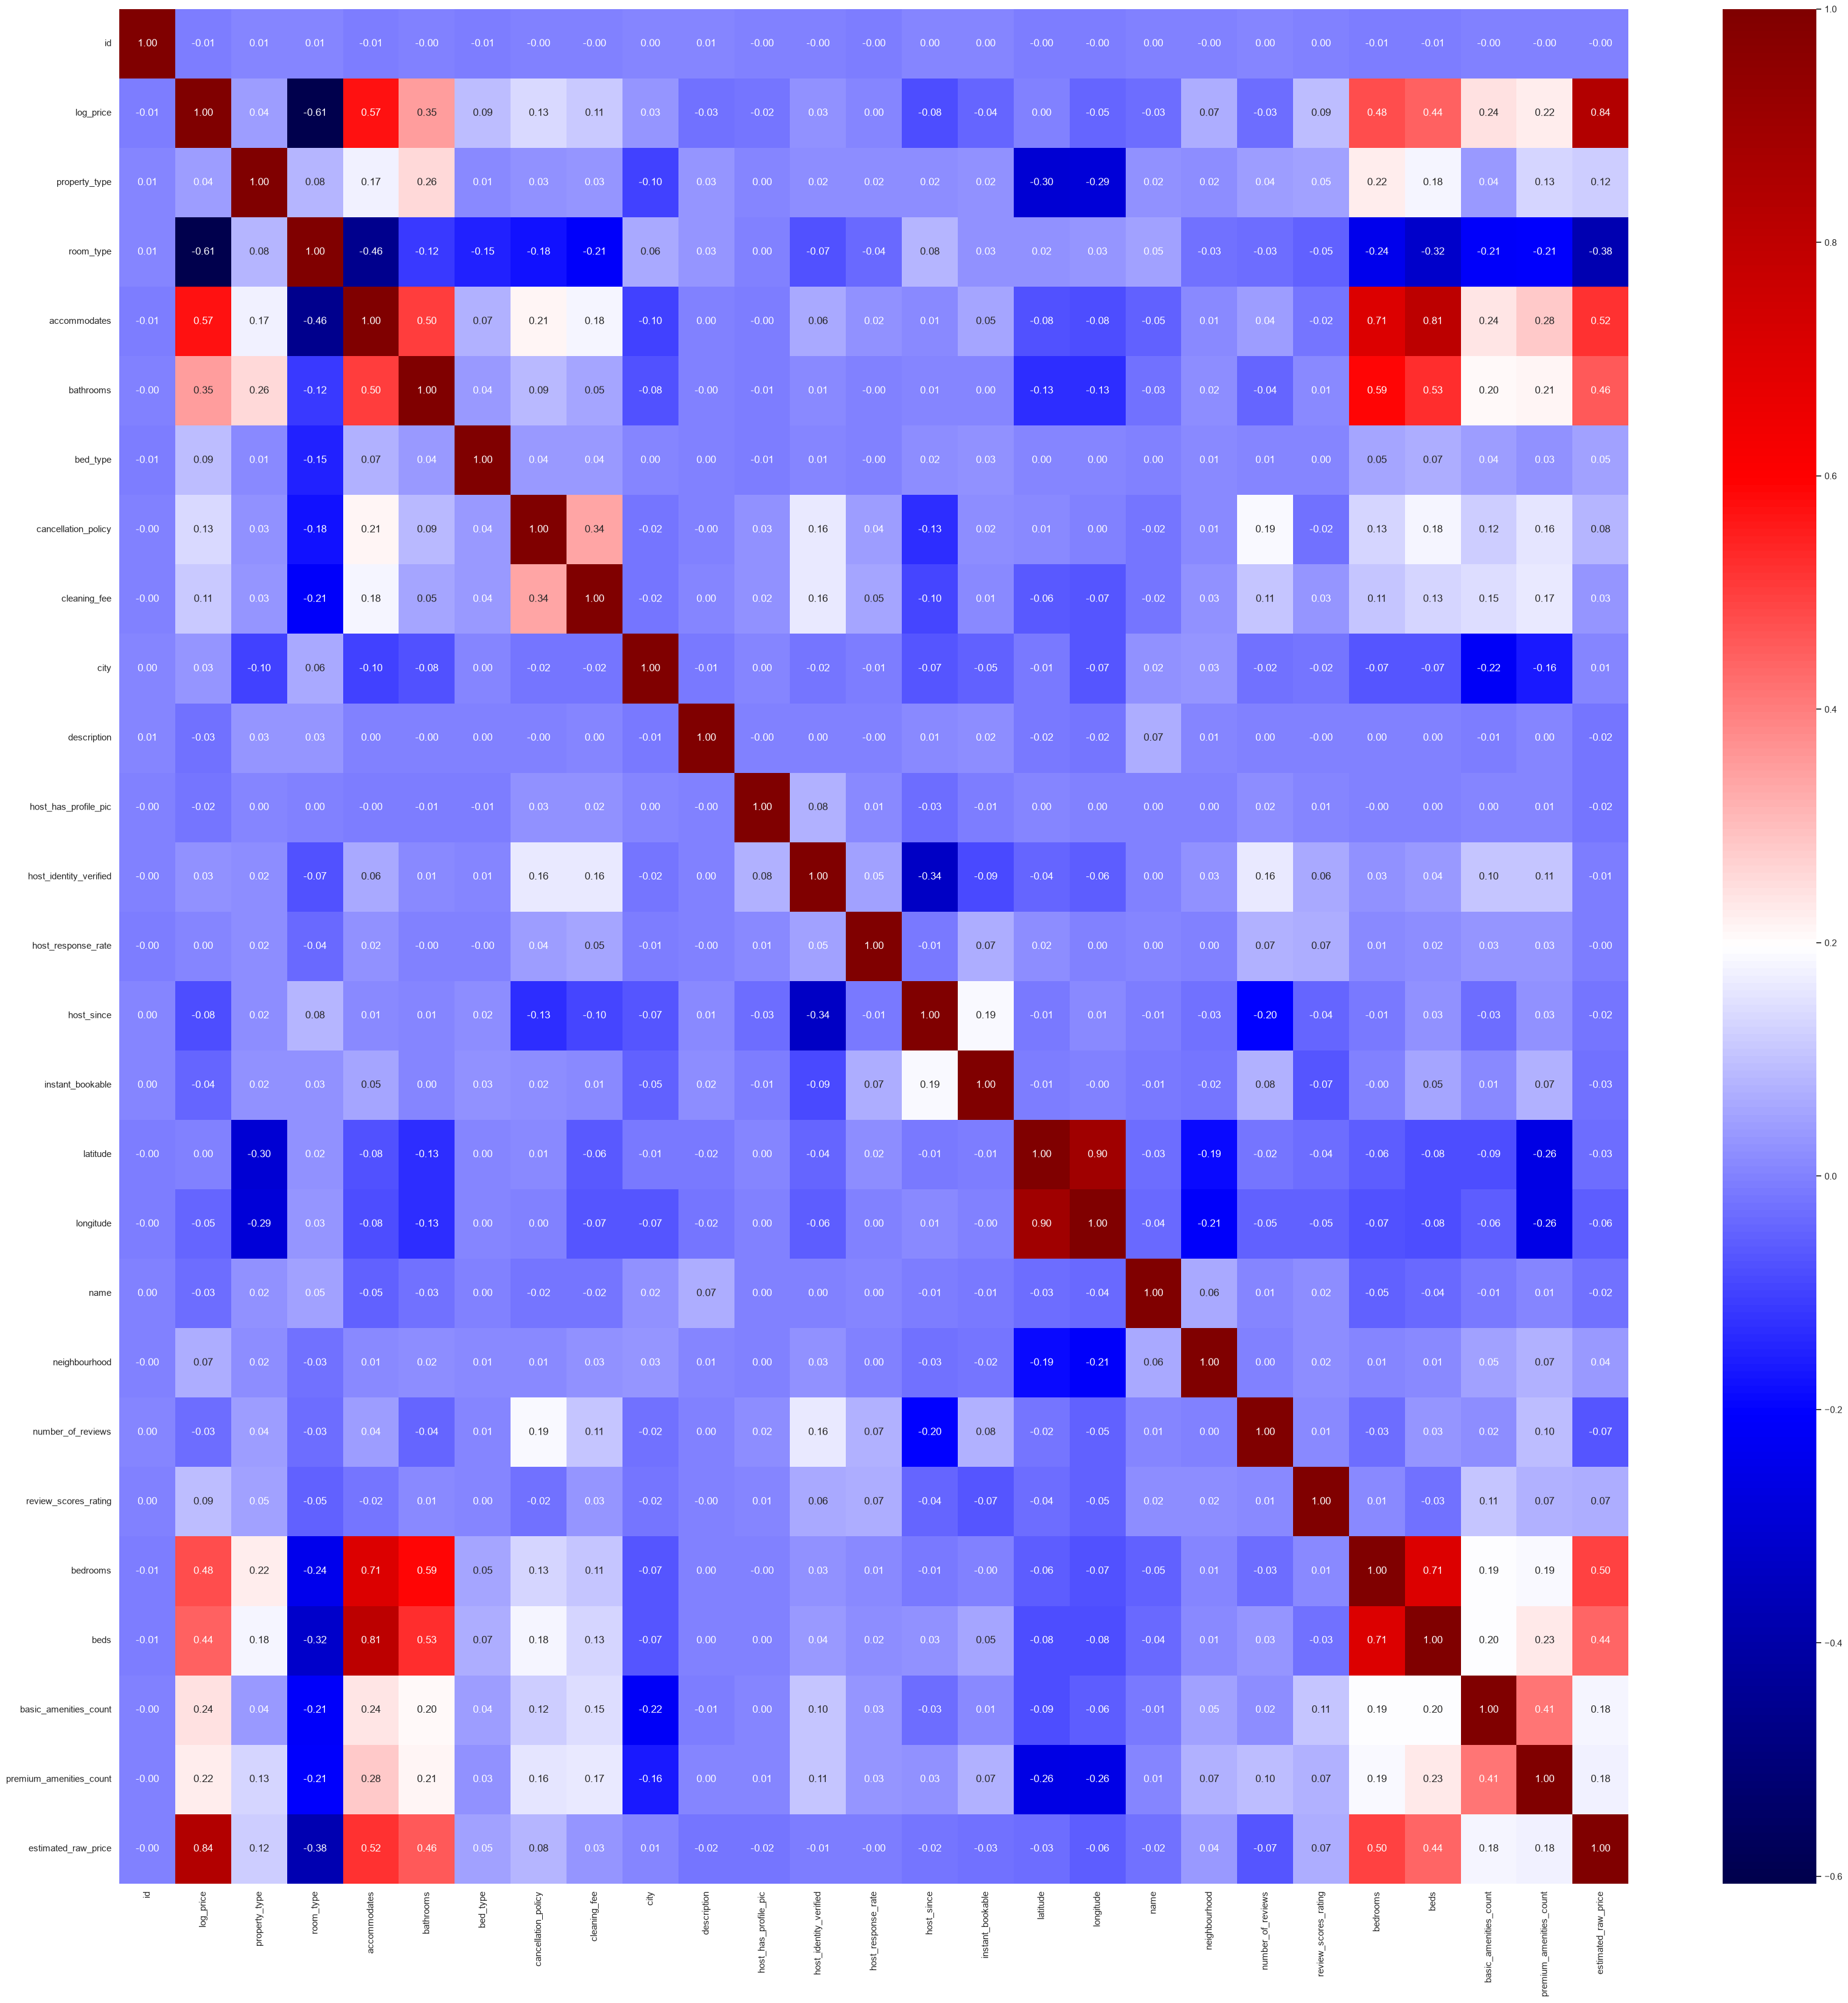

In [43]:
categorical_col = []
numerical_col = []
for column in df.columns:
    
    if df[column].dtypes != "float64" and df[column].dtypes != "int64":
        categorical_col.append(column)
    else:
        numerical_col.append(column)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in categorical_col:
    df[col] = le.fit_transform(df[col])

pd.set_option("display.max_columns", None)
plt.figure(figsize = (40,40))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="seismic")
plt.show()

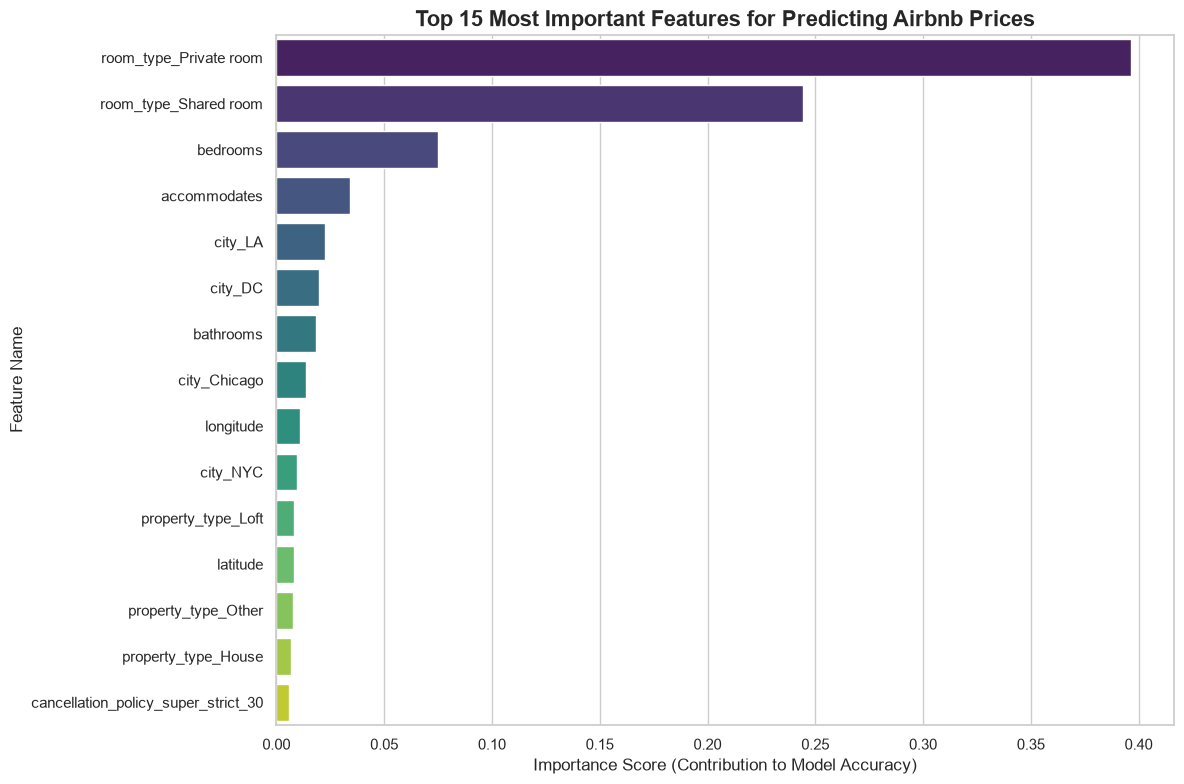

In [48]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the trained model and the preprocessor rules using relative paths
with open('../artifacts/model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('../artifacts/preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)

# 2. Reconstruct the Feature Names in the exact order they were transformed
# These are the exact numerical columns from your pipeline
numerical_columns = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds', 'latitude', 'longitude', 
    'number_of_reviews', 'review_scores_rating', 'basic_amenities_count', 
    'premium_amenities_count', 'host_response_rate', 'has_reviews',
    'host_has_profile_pic', 'host_identity_verified', 'instant_bookable'
]

# Extract the dynamically generated names from the One-Hot Encoder
ohe = preprocessor.named_transformers_['cat_pipeline'].named_steps['one_hot_encoder']
categorical_columns = ['room_type', 'property_type', 'cancellation_policy', 'city']
categorical_features = ohe.get_feature_names_out(categorical_columns)

# Combine them to match the 60 columns in your arrays
all_features = list(numerical_columns) + list(categorical_features)

# 3. Extract the math scores from the winning model
importances = model.feature_importances_

# 4. Bind the names and scores into a DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
})

# Sort from most important to least important
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 5. Plot the Top 15 Features
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance',hue='Feature', y='Feature', data=feature_importance_df.head(15), palette='viridis')

plt.title('Top 15 Most Important Features for Predicting Airbnb Prices', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score (Contribution to Model Accuracy)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\saish\AppData\Local\Temp\ipykernel_31540\1966045633.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include="object").columns.tolist()


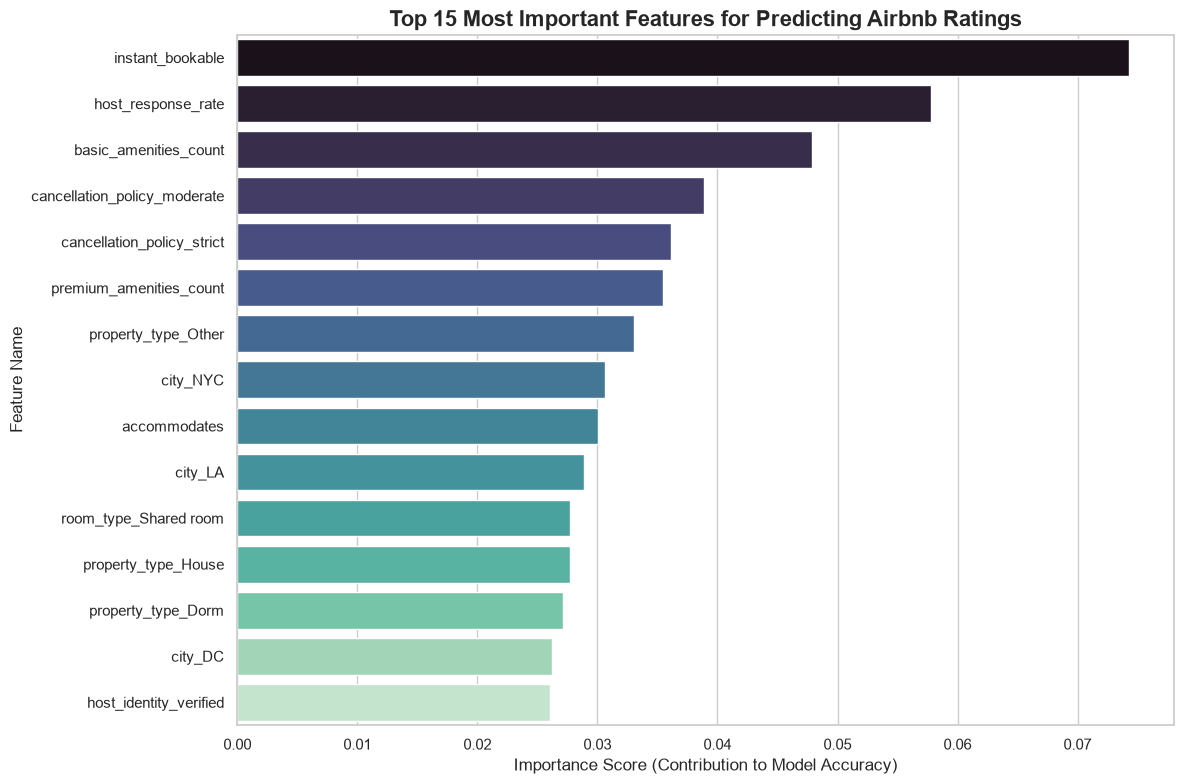

In [49]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load the rating model and preprocessor (using relative paths for the EDA folder)
with open('../artifacts/rating_model.pkl', 'rb') as f:
    rating_model = pickle.load(f)

with open('../artifacts/rating_preprocessor.pkl', 'rb') as f:
    rating_preprocessor = pickle.load(f)

# 2. Dynamically reconstruct the features
# We load a snippet of the data to get the exact column lists used during training
ratings_df = pd.read_csv('../artifacts/cleaned_data_ratings.csv')
columns_to_drop = ['id', 'name', 'description', 'host_since', 'neighbourhood', 'has_reviews', 'review_scores_rating']

# Drop the columns to isolate exactly what went into the X (features) array
X = ratings_df.drop(columns=[col for col in columns_to_drop if col in ratings_df.columns])

numerical_columns = X.select_dtypes(exclude="object").columns.tolist()
categorical_columns = X.select_dtypes(include="object").columns.tolist()

# Extract the dynamically generated names from the One-Hot Encoder
ohe = rating_preprocessor.named_transformers_['cat_pipeline'].named_steps['one_hot_encoder']
categorical_features = ohe.get_feature_names_out(categorical_columns)

# Combine them to match the exact array shape
all_features = numerical_columns + list(categorical_features)

# 3. Extract the math scores from the winning model
importances = rating_model.feature_importances_

# 4. Bind the names and scores into a DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
})

# Sort from most important to least important
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 5. Plot the Top 15 Features for Ratings
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))
# Using a different color palette ('mako') to distinguish from the pricing chart
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), hue='Feature', palette='mako', legend=False)

plt.title('Top 15 Most Important Features for Predicting Airbnb Ratings', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score (Contribution to Model Accuracy)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()